# Define constants

In [1]:
CLEAN_FEATURES_PATH = "../../features/opus-clean.npz"
NOISY_FEATURES_PATH = "../../features/opus-noisy.npz"
MODEL_SAVE_PATH = "../../models/opus-50e-DR40_2"
RANDOM_STATE = 43
CNN_VALIDATION_SPLIT = 0.1
CNN_TEST_SIZE = 0.1
CNN_EPOCHS = 50
CNN_BATCH_SIZE = 32
CNN_DENSE_UNITS = 64
CNN_DROPOUT_RATE = 0.4

KFOLD_N_SPLITS = 5
KFOLD_VALIDATION_SPLIT = CNN_VALIDATION_SPLIT
KFOLD_TEST_SIZE = CNN_TEST_SIZE
KFOLD_EPOCHS = CNN_EPOCHS
KFOLD_BATCH_SIZE = CNN_BATCH_SIZE

SKFOLD_N_SPLITS = KFOLD_N_SPLITS
SKFOLD_VALIDATION_SPLIT = CNN_VALIDATION_SPLIT
SKFOLD_TEST_SIZE = CNN_TEST_SIZE
SKFOLD_EPOCHS = CNN_EPOCHS
SKFOLD_BATCH_SIZE = CNN_BATCH_SIZE

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # disable tensorflow cuda warning messages
os.environ['TF_DETERMINISTIC_OPS'] = '1' # force deterministic TF ops
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
import random
import numpy as np
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Training

### Load features

In [2]:
data = np.load(CLEAN_FEATURES_PATH)
features = data['features']
labels = data['labels']

### Split data


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    features,
    categorical_labels,
    test_size=CNN_TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=categorical_labels
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Length of training set: {len(X_train)}")
print(f"Length of testing set: {len(X_test)}")

Shape of X_train: (6480, 36, 200)
Shape of X_test: (720, 36, 200)
Shape of y_train: (6480, 36)
Shape of y_test: (720, 36)
Length of training set: 6480
Length of testing set: 720


### Build model


In [4]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Get input shape and number of classes
input_shape = (features.shape[1], features.shape[2], 1) # Add channel dimension based on original features shape
num_classes = y_train.shape[1]

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(CNN_DENSE_UNITS, activation='relu'),
    Dropout(CNN_DROPOUT_RATE),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 34, 198, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 17, 99, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 15, 97, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 48, 64)         0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 21504)             0         
                                                                 
 dense (Dense)               (None, 64)                1

### Train model

In [5]:
history = model.fit(X_train, y_train, epochs=CNN_EPOCHS, batch_size=CNN_BATCH_SIZE, validation_split=CNN_VALIDATION_SPLIT)

Epoch 1/50


I0000 00:00:1777137057.198860  379582 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


183/183 [==============================] - 4s 12ms/step - loss: 1.3056 - accuracy: 0.6163 - val_loss: 0.0199 - val_accuracy: 1.0000
Epoch 2/50
183/183 [==============================] - 2s 8ms/step - loss: 0.2757 - accuracy: 0.9019 - val_loss: 0.0027 - val_accuracy: 1.0000
Epoch 3/50
183/183 [==============================] - 2s 9ms/step - loss: 0.1789 - accuracy: 0.9321 - val_loss: 3.6660e-04 - val_accuracy: 1.0000
Epoch 4/50
183/183 [==============================] - 2s 8ms/step - loss: 0.1406 - accuracy: 0.9489 - val_loss: 1.6923e-04 - val_accuracy: 1.0000
Epoch 5/50
183/183 [==============================] - 2s 9ms/step - loss: 0.1338 - accuracy: 0.9503 - val_loss: 3.3614e-05 - val_accuracy: 1.0000
Epoch 6/50
183/183 [==============================] - 2s 8ms/step - loss: 0.1111 - accuracy: 0.9576 - val_loss: 2.2696e-05 - val_accuracy: 1.0000
Epoch 7/50
183/183 [==============================] - 2s 8ms/step - loss: 0.1069 - accuracy: 0.9590 - val_loss: 8.4738e-05 - val_accuracy: 1.0

### Class distribution

In [6]:
from collections import Counter
import numpy as np

import matplotlib.pyplot as plt

# Keras validation_split takes the last fraction of training data
val_size = int(len(y_train) * CNN_VALIDATION_SPLIT)
y_train_actual = y_train[:-val_size]
y_val          = y_train[-val_size:]

# Get class distribution for train, validation, and test sets
train_dist = Counter(np.argmax(y_train_actual, axis=1))
val_dist   = Counter(np.argmax(y_val,          axis=1))
test_dist  = Counter(np.argmax(y_test,         axis=1))

class_names = label_encoder.classes_
x = np.arange(len(class_names))
width = 0.4

train_counts = [train_dist.get(i, 0) for i in range(len(class_names))]
val_counts   = [val_dist.get(i, 0)   for i in range(len(class_names))]
test_counts  = [test_dist.get(i, 0)  for i in range(len(class_names))]

# Print summary table
print(f"\n{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 56)
for i, name in enumerate(class_names):
  tr = train_dist.get(i, 0)
  vl = val_dist.get(i, 0)
  te = test_dist.get(i, 0)
  print(f"{name:<20} {tr:>8} {vl:>8} {te:>8} {tr+vl+te:>8}")
print("-" * 56)
print(f"{'TOTAL':<20} {sum(train_counts):>8} {sum(val_counts):>8} {sum(test_counts):>8} {sum(train_counts)+sum(val_counts)+sum(test_counts):>8}")



Class                   Train      Val     Test    Total
--------------------------------------------------------
A#_diminished_4           163       17       20      200
A#_major_4                167       13       20      200
A#_minor_4                164       16       20      200
A_diminished_4            164       16       20      200
A_major_4                 168       12       20      200
A_minor_4                 161       19       20      200
B_diminished_4            165       15       20      200
B_major_4                 157       23       20      200
B_minor_4                 160       20       20      200
C#_diminished_4           151       29       20      200
C#_major_4                163       17       20      200
C#_minor_4                169       11       20      200
C_diminished_4            156       24       20      200
C_major_4                 164       16       20      200
C_minor_4                 165       15       20      200
D#_diminished_4           161 

### Training history

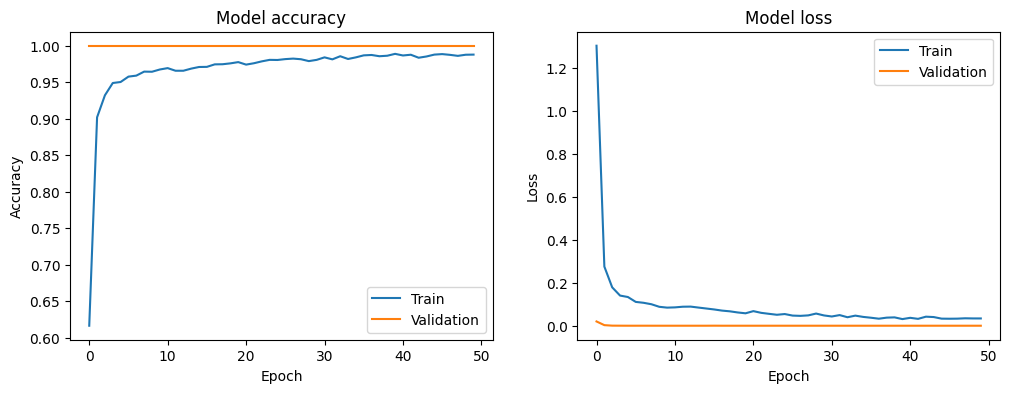

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.show()

### Confusion Matrix

23/23 [==============================] - 0s 3ms/step


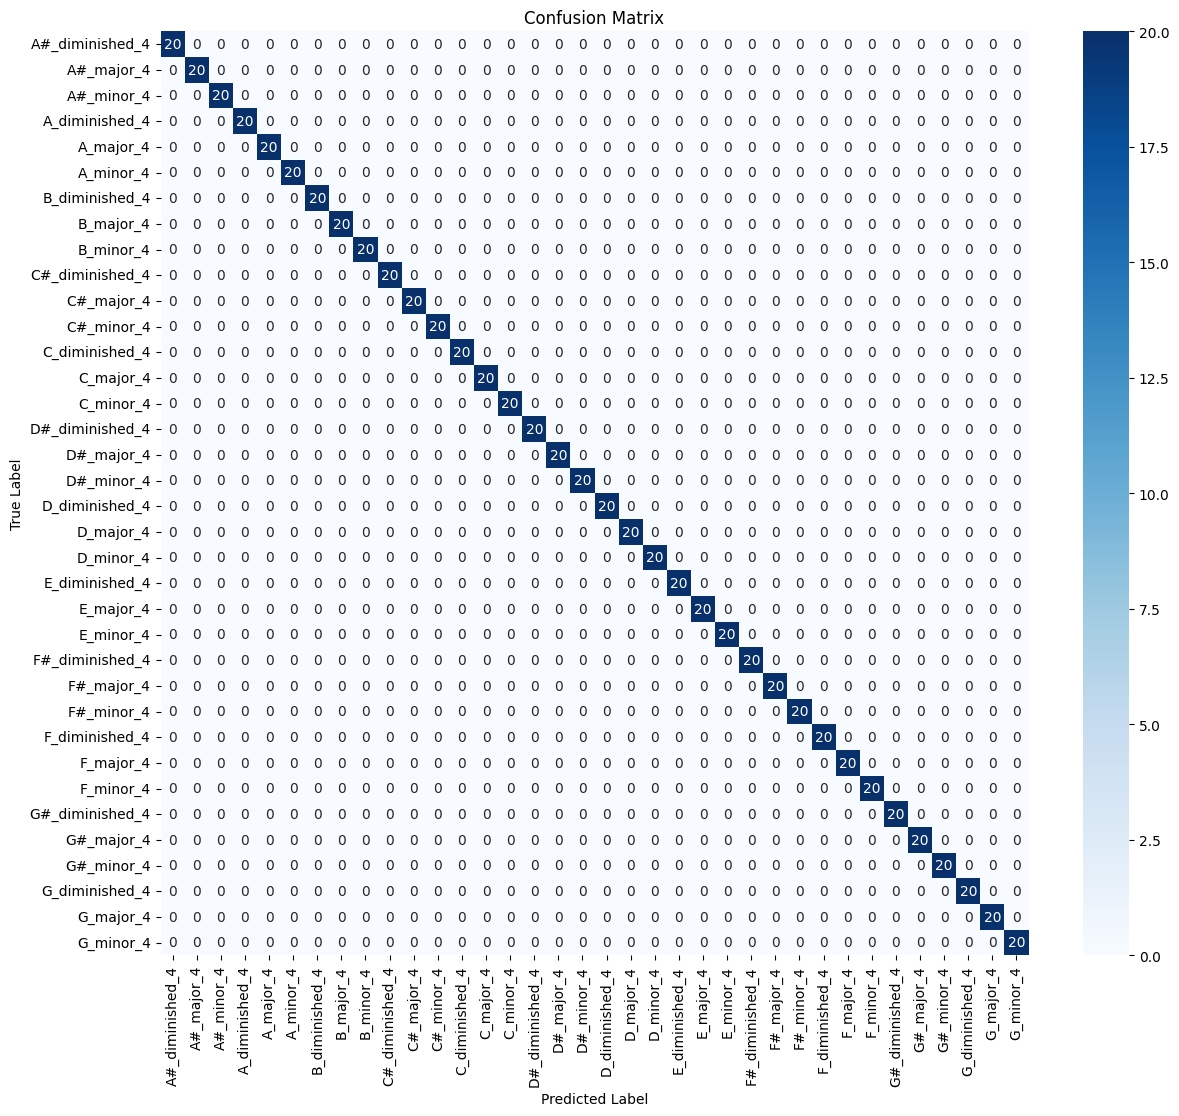

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Get class labels from the label encoder
class_labels = label_encoder.classes_

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [9]:
from sklearn.metrics import classification_report

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy}")
print(f"Test Loss: {loss}")

# Generate classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels)
print("Classification Report:\n", report)

Test Accuracy: 1.0
Test Loss: 5.397525271177983e-08
Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      1.00      1.00        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminish

### Save Model

In [10]:
# Save the model
model.save(MODEL_SAVE_PATH + '.h5')
print(f"Model saved to {MODEL_SAVE_PATH}.h5")

Model saved to ../../models/opus-50e-DR40_2.h5


/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Convert model to tfjs

In [11]:
!TF_DETERMINISTIC_OPS=0 tensorflowjs_converter --input_format=keras --output_format=tfjs_graph_model {MODEL_SAVE_PATH}.h5 {MODEL_SAVE_PATH} && echo TensorFlow.js model saved to {MODEL_SAVE_PATH}

Traceback (most recent call last):
  File "/home/seya/code/chord-detection/training/.venv/bin/tensorflowjs_converter", line 4, in <module>
    from tensorflowjs.converters.converter import pip_main
  File "/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/tensorflowjs/__init__.py", line 21, in <module>
    from tensorflowjs import converters
  File "/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/tensorflowjs/converters/__init__.py", line 21, in <module>
    from tensorflowjs.converters.converter import convert
  File "/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/tensorflowjs/converters/converter.py", line 38, in <module>
    from tensorflowjs.converters import tf_saved_model_conversion_v2
  File "/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/tensorflowjs/converters/tf_saved_model_conversion_v2.py", line 51, in <module>
    import tensorflow_hub as hub
  File "/home/seya/c

# Cross Validation

## K-Fold cross-validation

### Define constants

In [12]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_cnn_model(input_shape, num_classes):
    """Defines and compiles the CNN model architecture."""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

input_shape = (features.shape[1], features.shape[2], 1)
num_classes = categorical_labels.shape[1]

### Train

In [13]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import tensorflow as tf

# Instantiate KFold
kf = KFold(n_splits=KFOLD_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Initialize lists to store performance metrics for each fold
fold_accuracies = []
fold_losses = []
fold_histories = []
fold_confusion_matrices = []

for fold, (train_val_index, test_index) in enumerate(kf.split(features, encoded_labels)):
    print(f"\n--- Fold {fold+1}/{kf.n_splits} ---")

    # Set per-fold seed so each fold is independently reproducible
    tf.random.set_seed(RANDOM_STATE + fold)
    np.random.seed(RANDOM_STATE + fold)

    # Split train_val_index
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=encoded_labels[train_val_index]  # preserve class distribution
    )

    X_train_fold = np.expand_dims(features[train_index], axis=-1)
    X_val_fold   = np.expand_dims(features[val_index],   axis=-1)
    X_test_fold  = np.expand_dims(features[test_index],  axis=-1)

    y_train_fold = categorical_labels[train_index]
    y_val_fold   = categorical_labels[val_index]
    y_test_fold  = categorical_labels[test_index]

    model = create_cnn_model(input_shape, num_classes)

    print(f"Training model for Fold {fold+1}...")
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=KFOLD_EPOCHS,
        batch_size=KFOLD_BATCH_SIZE,
        validation_data=(X_val_fold, y_val_fold),  # enables val metrics per epoch
        validation_split=KFOLD_VALIDATION_SPLIT,
        verbose=0
    )
    fold_histories.append(history)

    print(f"Evaluating model for Fold {fold+1}...")
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)

    y_pred_fold = model.predict(X_test_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred_fold, axis=1)
    y_true_classes = np.argmax(y_test_fold, axis=1)
    fold_confusion_matrices.append(confusion_matrix(y_true_classes, y_pred_classes))

    fold_accuracies.append(accuracy)
    fold_losses.append(loss)
    print(f"Fold {fold+1} - Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

print("\nK-Fold Cross-Validation complete.")



--- Fold 1/5 ---
Training model for Fold 1...
Evaluating model for Fold 1...
Fold 1 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 2/5 ---
Training model for Fold 2...
Evaluating model for Fold 2...
Fold 2 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 3/5 ---
Training model for Fold 3...
Evaluating model for Fold 3...
Fold 3 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 4/5 ---
Training model for Fold 4...
Evaluating model for Fold 4...
Fold 4 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 5/5 ---
Training model for Fold 5...
Evaluating model for Fold 5...
Fold 5 - Test Accuracy: 1.0000, Test Loss: 0.0000

K-Fold Cross-Validation complete.


### Show class distribution

In [14]:
from collections import Counter
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

for fold, (train_val_index, test_index) in enumerate(kf.split(features, encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=encoded_labels[train_val_index]
    )

    train_dist = Counter(encoded_labels[train_index])
    val_dist   = Counter(encoded_labels[val_index])
    test_dist  = Counter(encoded_labels[test_index])

    classes = sorted(train_dist.keys())
    class_names = label_encoder.inverse_transform(classes)

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(classes, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} {sum(test_dist.values()):>8}  {len(encoded_labels):>8}")

print("\n" + "=" * 65)

              Class Distribution per Fold

  Fold 1
  Class                   Train      Val     Test     Total
  -------------------- -------- -------- --------  --------
  A#_diminished_4           152       17       31       200
  A#_major_4                142       16       42       200
  A#_minor_4                132       15       53       200
  A_diminished_4            148       17       35       200
  A_major_4                 143       16       41       200
  A_minor_4                 148       16       36       200
  B_diminished_4            145       16       39       200
  B_major_4                 137       15       48       200
  B_minor_4                 149       16       35       200
  C#_diminished_4           140       16       44       200
  C#_major_4                145       16       39       200
  C#_minor_4                143       16       41       200
  C_diminished_4            148       16       36       200
  C_major_4                 150       17       3

### Confusion Matrix per Fold

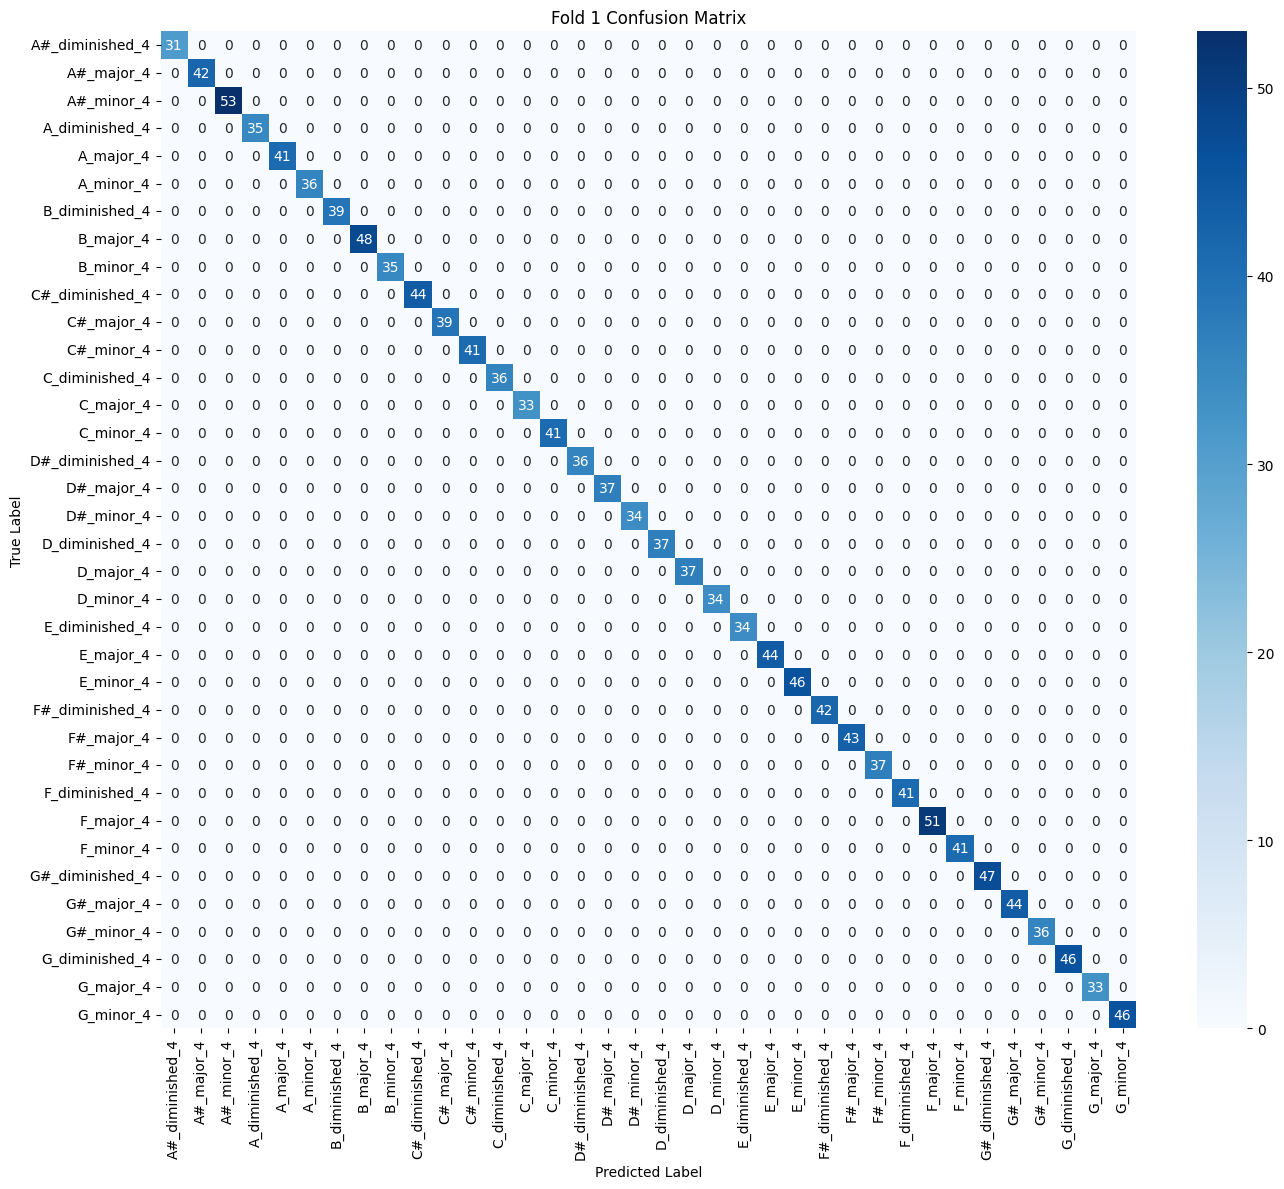

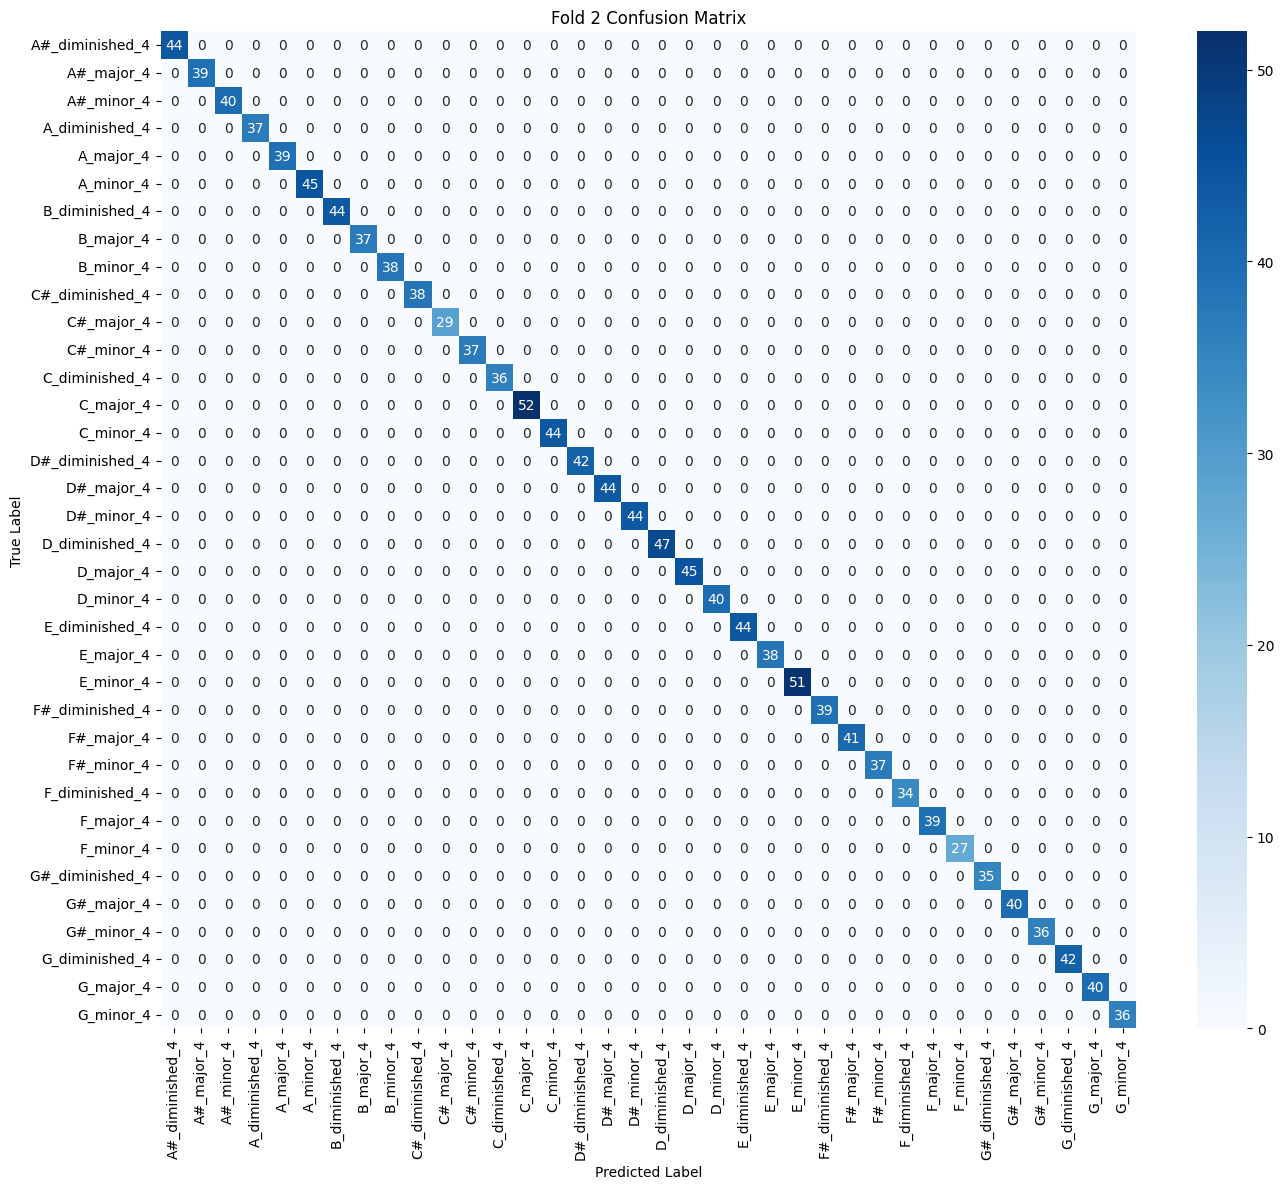

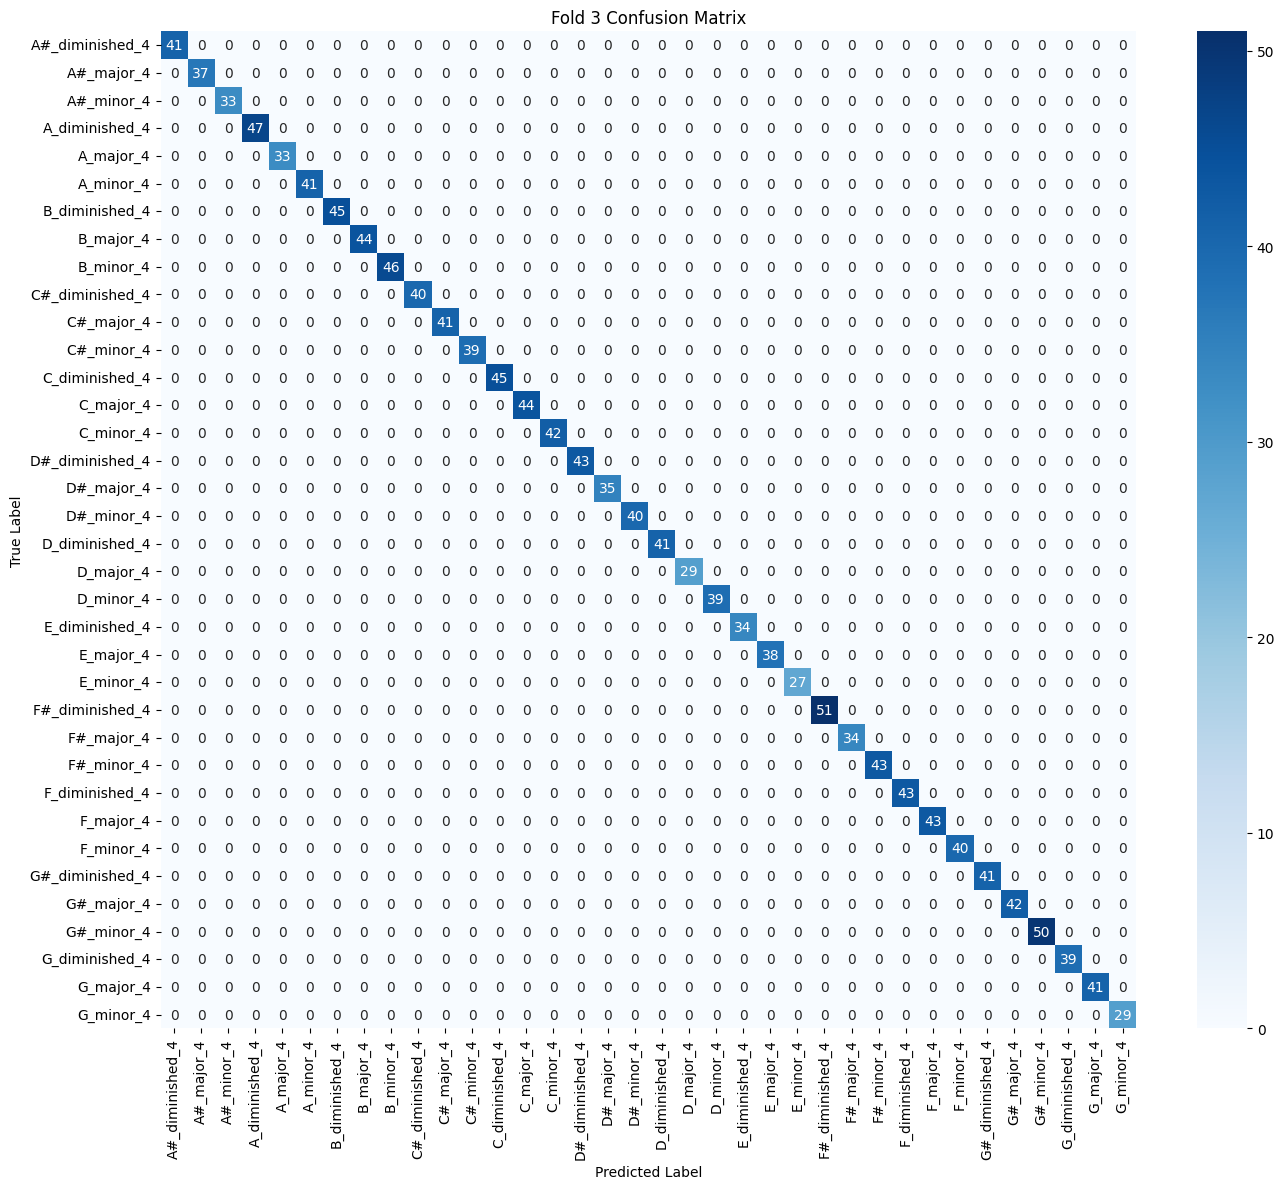

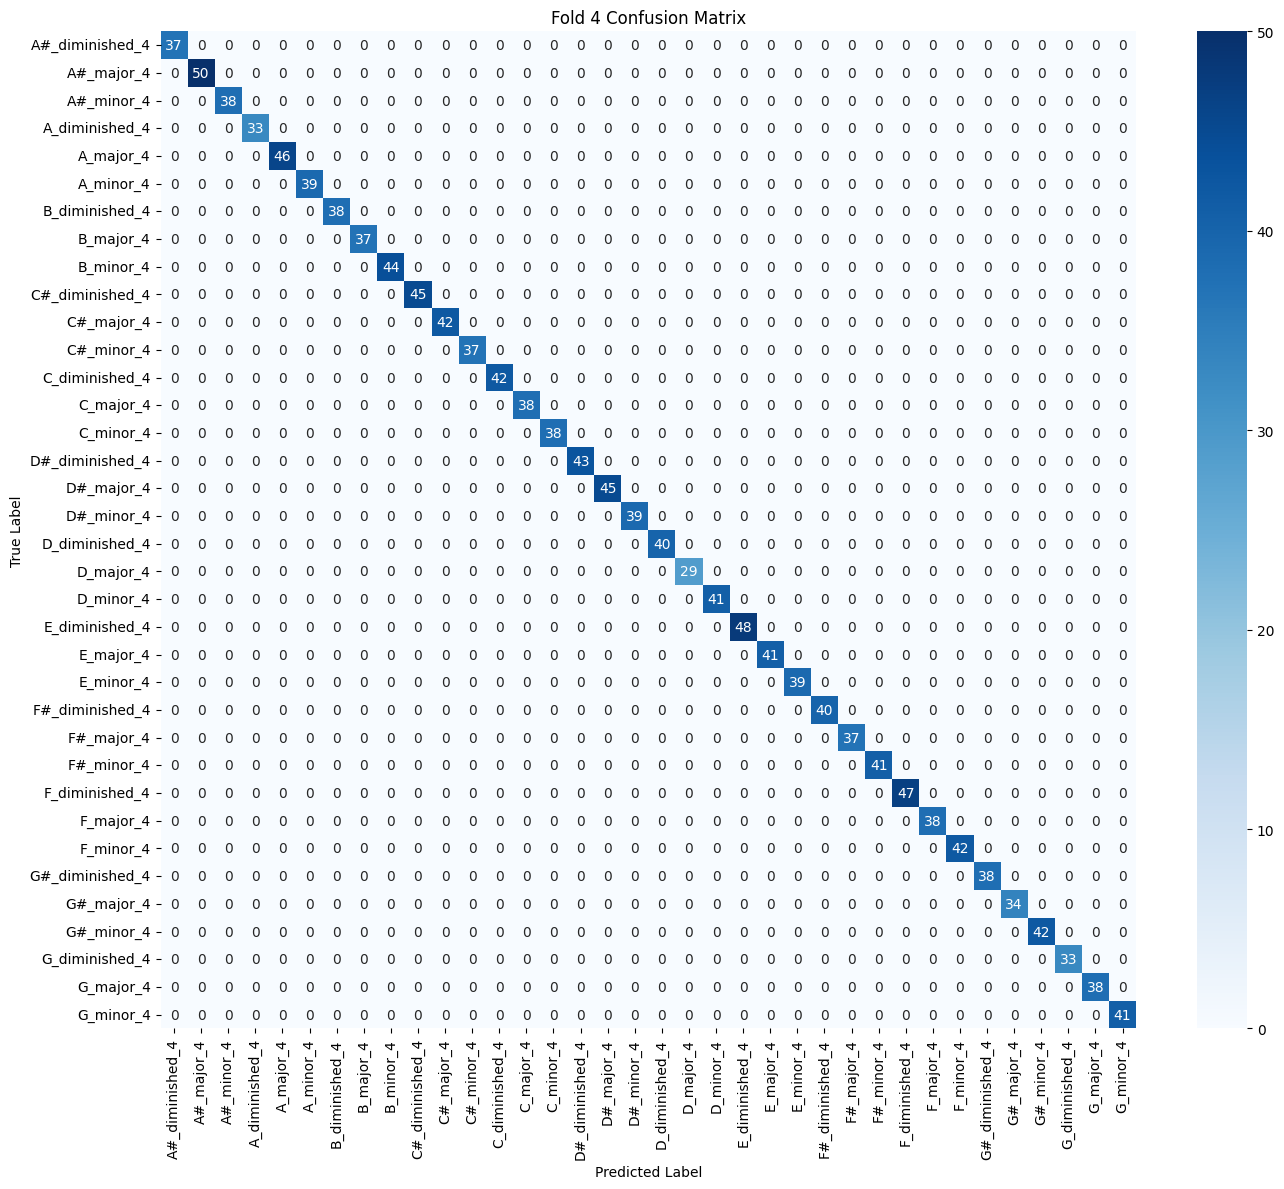

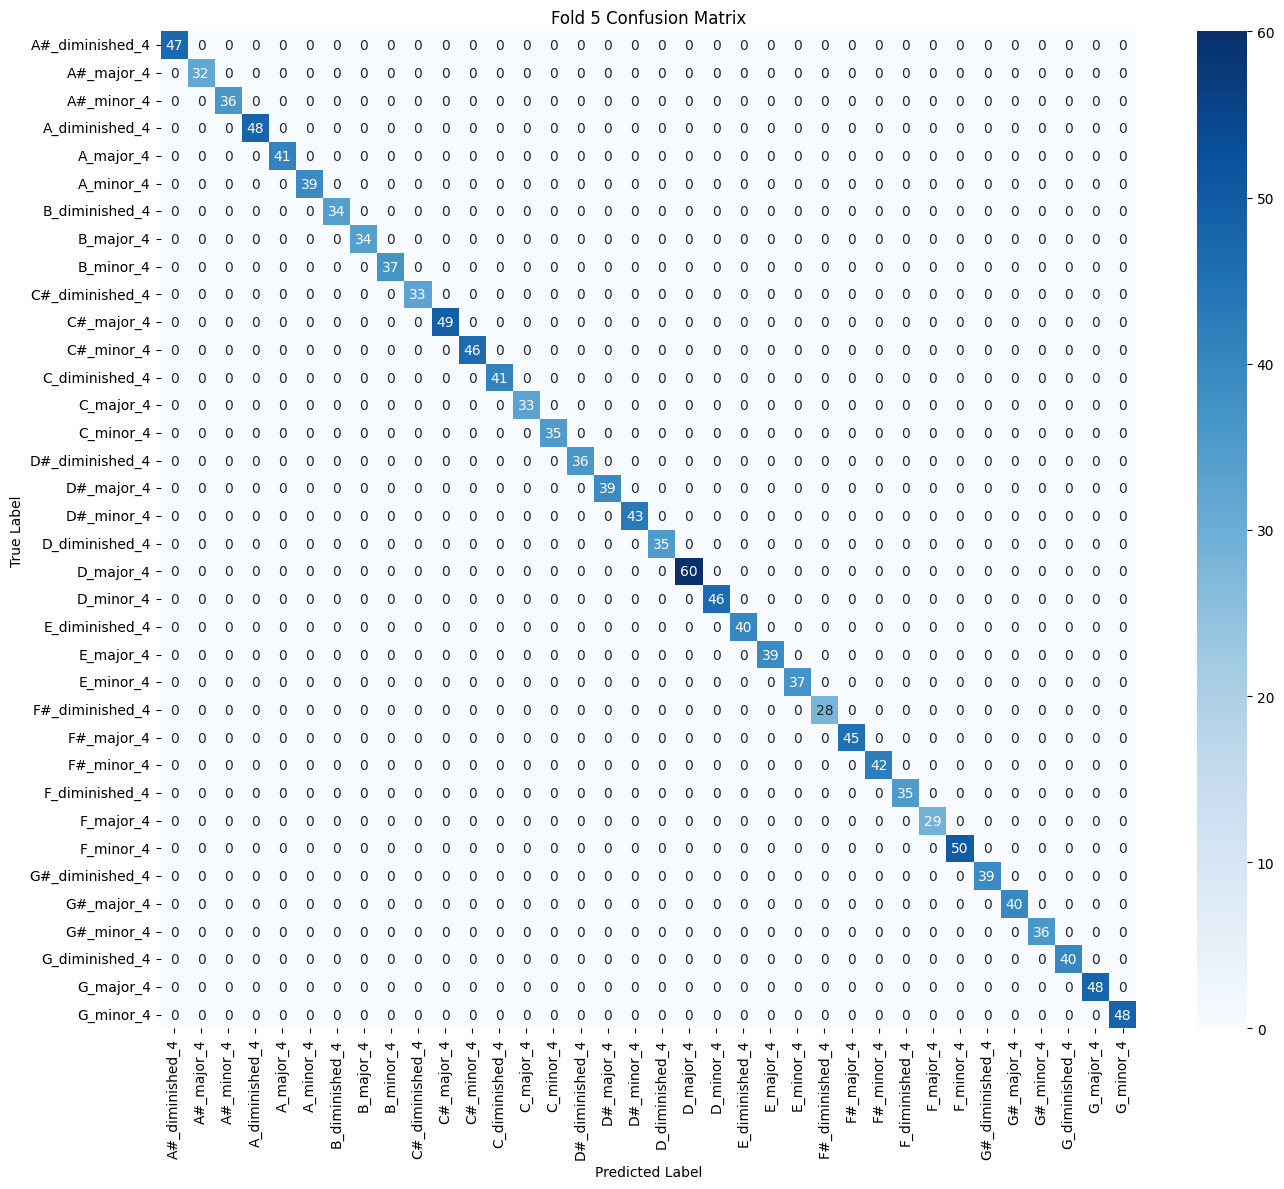

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

class_labels = label_encoder.classes_

for i, cm in enumerate(fold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

### Accuracy & Loss Plot

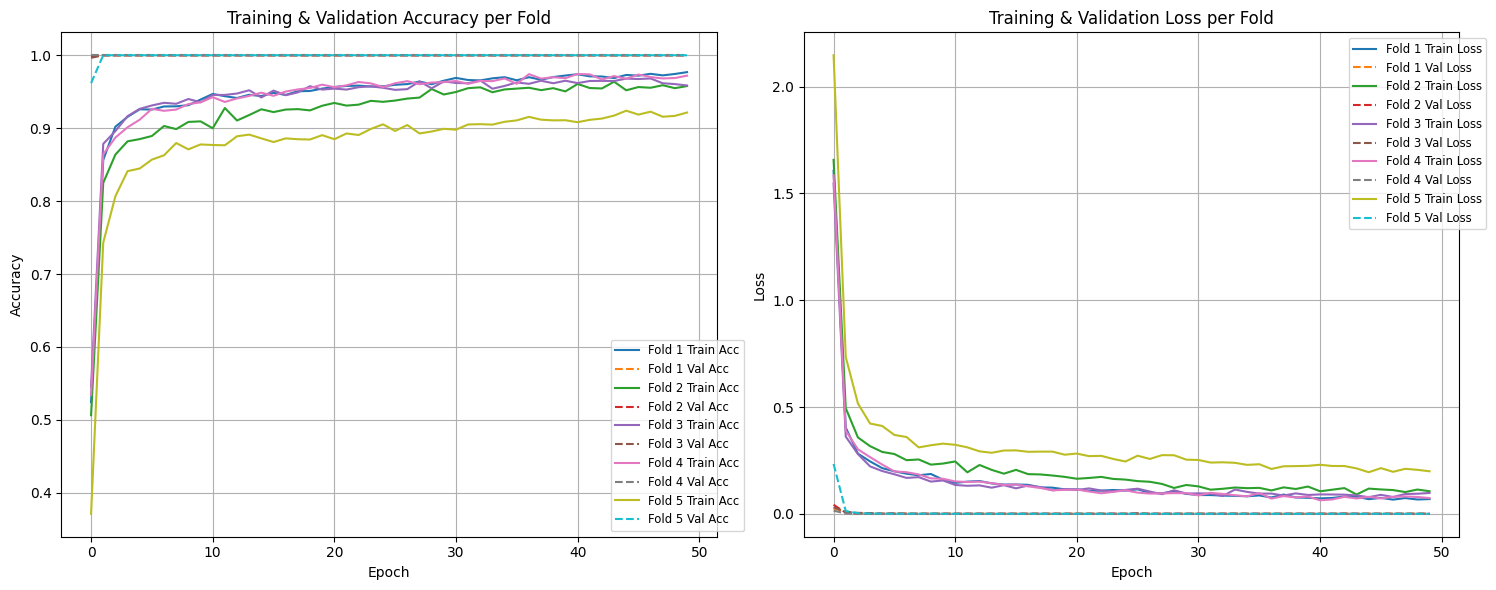

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
for i, history_obj in enumerate(fold_histories):
    plt.plot(history_obj.history['accuracy'],
             label=f'Fold {i+1} Train Acc')
    plt.plot(history_obj.history['val_accuracy'],
             linestyle='--', label=f'Fold {i+1} Val Acc')

plt.title('Training & Validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right', bbox_to_anchor=(1.05, 0), fontsize='small')
plt.grid(True)

# --- Loss ---
plt.subplot(1, 2, 2)
for i, history_obj in enumerate(fold_histories):
    plt.plot(history_obj.history['loss'],
             label=f'Fold {i+1} Train Loss')
    plt.plot(history_obj.history['val_loss'],
             linestyle='--', label=f'Fold {i+1} Val Loss')

plt.title('Training & Validation Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

### Mean & Std Deviation

In [17]:
import numpy as np

# Collect final-epoch train/val metrics from each fold's history
train_accs = [h.history['accuracy'][-1]     for h in fold_histories]
val_accs   = [h.history['val_accuracy'][-1] for h in fold_histories]
train_losses = [h.history['loss'][-1]       for h in fold_histories]
val_losses   = [h.history['val_loss'][-1]   for h in fold_histories]

print("=" * 73)
print("         Stratified K-Fold Cross-Validation Summary (per fold)")
print("=" * 73)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
for i in range(len(fold_accuracies)):
    print(f"  Fold {i+1:>1}  {train_accs[i]:>10.4f}  {val_accs[i]:>10.4f}  {fold_accuracies[i]:>10.4f}  {train_losses[i]:>11.4f}  {val_losses[i]:>10.4f}  {fold_losses[i]:>10.4f}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(f"  {'Mean':>6}  {np.mean(train_accs):>10.4f}  {np.mean(val_accs):>10.4f}  {np.mean(fold_accuracies):>10.4f}  {np.mean(train_losses):>11.4f}  {np.mean(val_losses):>10.4f}  {np.mean(fold_losses):>10.4f}")
print(f"  {'Std':>6}  {np.std(train_accs):>10.4f}  {np.std(val_accs):>10.4f}  {np.std(fold_accuracies):>10.4f}  {np.std(train_losses):>11.4f}  {np.std(val_losses):>10.4f}  {np.std(fold_losses):>10.4f}")
print("=" * 73)

         Stratified K-Fold Cross-Validation Summary (per fold)
           Train Acc     Val Acc    Test Acc   Train Loss    Val Loss   Test Loss
  ------  ----------  ----------  ----------  -----------  ----------  ----------
  Fold 1      0.9769      1.0000      1.0000       0.0690      0.0000      0.0000
  Fold 2      0.9578      1.0000      1.0000       0.1057      0.0000      0.0000
  Fold 3      0.9585      1.0000      1.0000       0.0975      0.0000      0.0000
  Fold 4      0.9720      1.0000      1.0000       0.0736      0.0000      0.0000
  Fold 5      0.9215      1.0000      1.0000       0.1991      0.0000      0.0000
  ------  ----------  ----------  ----------  -----------  ----------  ----------
    Mean      0.9573      1.0000      1.0000       0.1090      0.0000      0.0000
     Std      0.0194      0.0000      0.0000       0.0471      0.0000      0.0000


### Per Class Accuracies

Per-Class Accuracy (Mean ± Std across folds)
              Class  Mean Acc  Std Acc
1   A#_diminished_4       1.0      0.0
2        A#_major_4       1.0      0.0
3         D_minor_4       1.0      0.0
4    E_diminished_4       1.0      0.0
5         E_major_4       1.0      0.0
6         E_minor_4       1.0      0.0
7   F#_diminished_4       1.0      0.0
8        F#_major_4       1.0      0.0
9        F#_minor_4       1.0      0.0
10   F_diminished_4       1.0      0.0
11        F_major_4       1.0      0.0
12        F_minor_4       1.0      0.0
13  G#_diminished_4       1.0      0.0
14       G#_major_4       1.0      0.0
15       G#_minor_4       1.0      0.0
16   G_diminished_4       1.0      0.0
17        G_major_4       1.0      0.0
18        D_major_4       1.0      0.0
19   D_diminished_4       1.0      0.0
20       D#_minor_4       1.0      0.0
21        B_minor_4       1.0      0.0
22       A#_minor_4       1.0      0.0
23   A_diminished_4       1.0      0.0
24        A_major_4

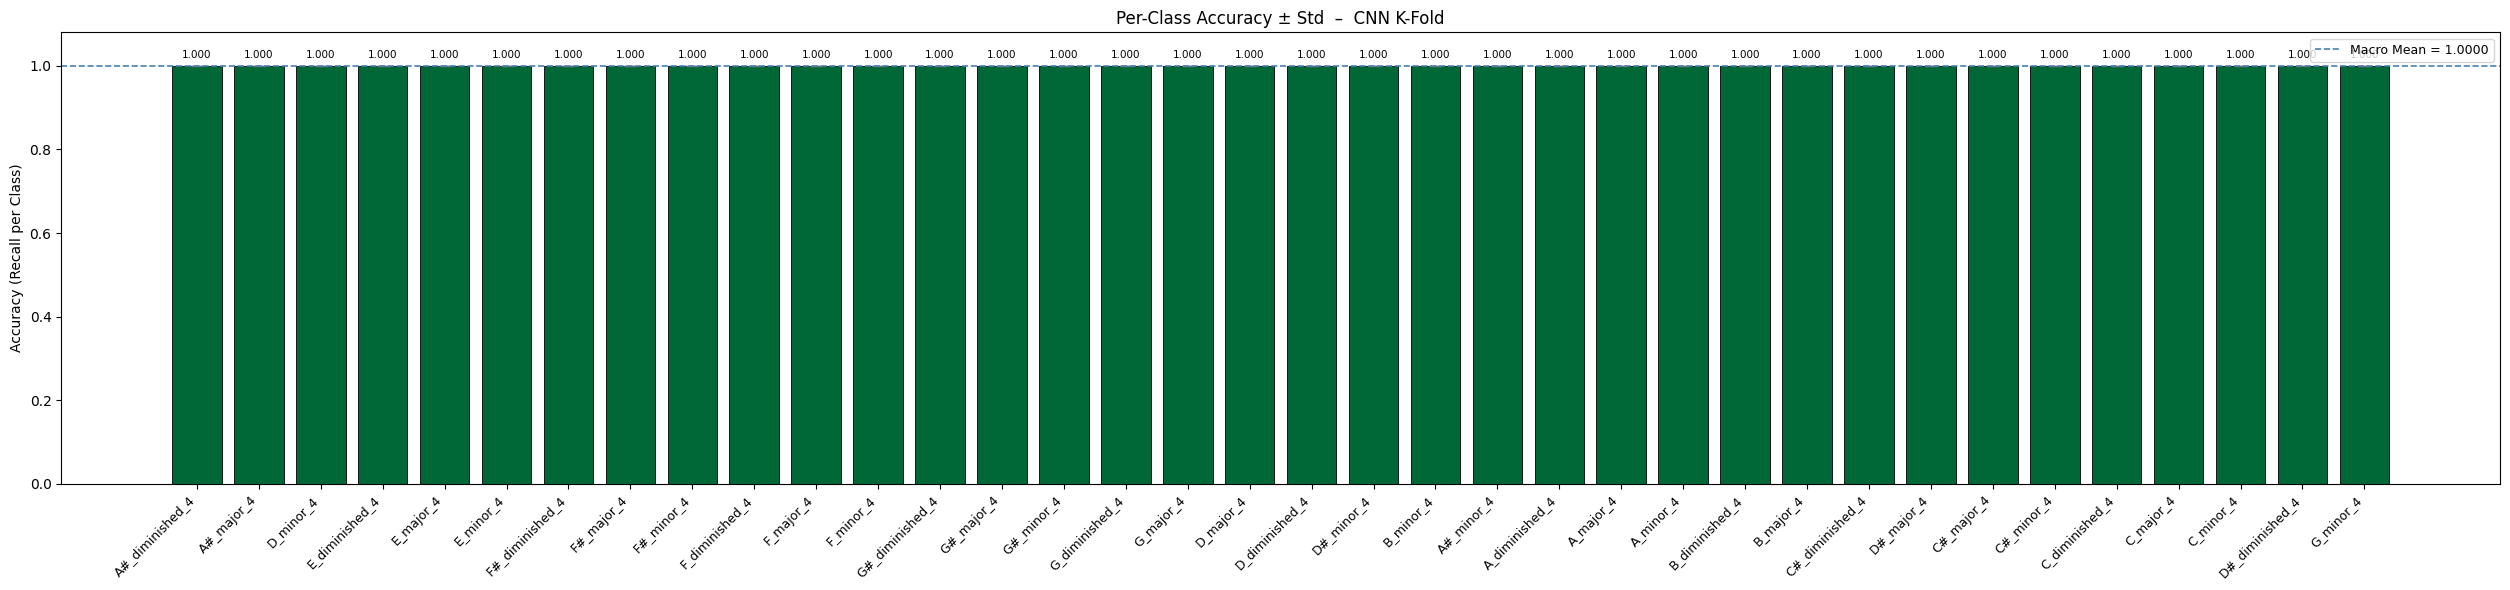

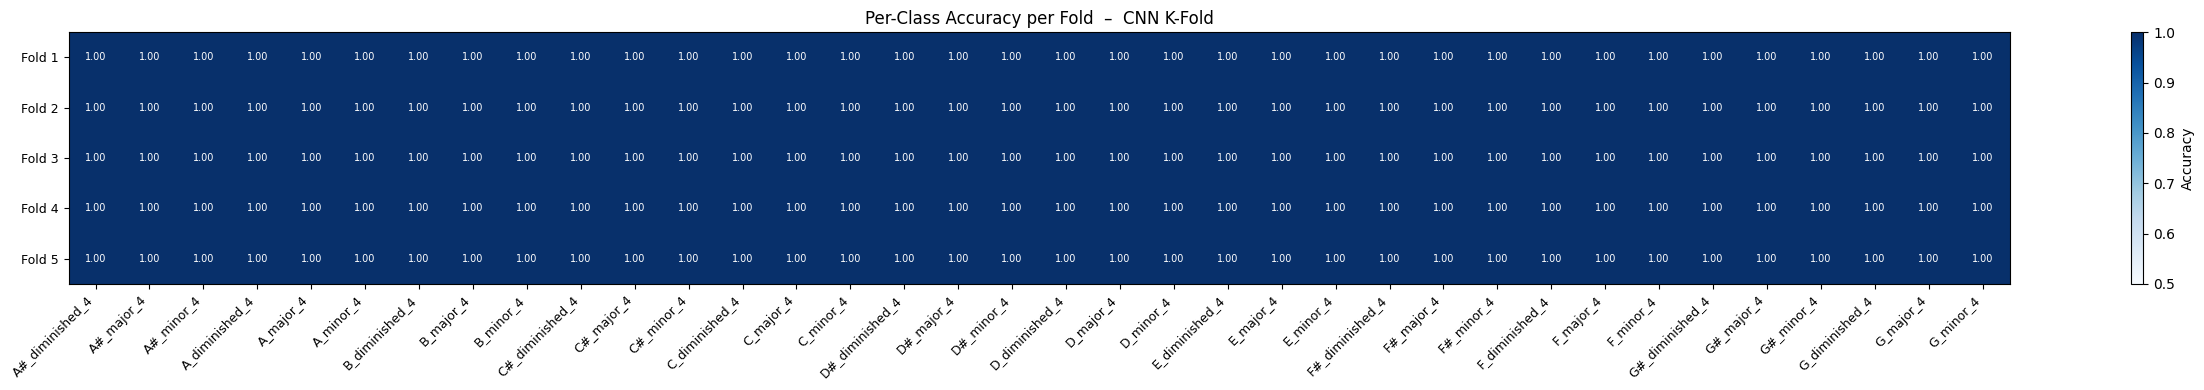

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Extract per-class accuracy for every fold ──────────────────────────────
class_names = label_encoder.classes_          # shape: (n_classes,)
n_folds     = len(fold_confusion_matrices)
n_classes   = len(class_names)

# per_class_acc[fold, class] = recall of that class in that fold
per_class_acc = np.zeros((n_folds, n_classes))

for fold_idx, cm in enumerate(fold_confusion_matrices):
    row_sums = cm.sum(axis=1)                     # true counts per class
    with np.errstate(divide='ignore', invalid='ignore'):
        acc = np.where(row_sums > 0, cm.diagonal() / row_sums, np.nan)
    per_class_acc[fold_idx] = acc

# ── 2. Mean & Std across folds ────────────────────────────────────────────────
mean_acc = np.nanmean(per_class_acc, axis=0)
std_acc  = np.nanstd(per_class_acc,  axis=0)

# ── 3. Build summary DataFrame ────────────────────────────────────────────────
df_class_acc = pd.DataFrame({
    "Class":    class_names,
    "Mean Acc": mean_acc,
    "Std Acc":  std_acc,
})
df_class_acc = df_class_acc.sort_values("Mean Acc", ascending=False).reset_index(drop=True)
df_class_acc.index += 1                           # rank starts at 1

print("Per-Class Accuracy (Mean ± Std across folds)")
print("=" * 45)
print(df_class_acc.to_string())

# ── 4. Bar chart with error bars ──────────────────────────────────────────────
sorted_classes = df_class_acc["Class"].values
sorted_mean    = df_class_acc["Mean Acc"].values
sorted_std     = df_class_acc["Std Acc"].values

colors = plt.cm.RdYlGn(sorted_mean)              # red=low, green=high

fig, ax = plt.subplots(figsize=(max(10, n_classes * 0.7), 6))
bars = ax.bar(
    range(n_classes), sorted_mean,
    yerr=sorted_std, capsize=4,
    color=colors, edgecolor="black", linewidth=0.6,
    error_kw={"elinewidth": 1.2, "ecolor": "dimgray"}
)

ax.set_xticks(range(n_classes))
ax.set_xticklabels(sorted_classes, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (Recall per Class)")
ax.set_title("Per-Class Accuracy ± Std  –  CNN K-Fold")
ax.set_ylim(0, 1.08)
ax.axhline(y=sorted_mean.mean(), color="steelblue",
           linestyle="--", linewidth=1.2, label=f"Macro Mean = {sorted_mean.mean():.4f}")
ax.legend(fontsize=9)

for i, (m, s) in enumerate(zip(sorted_mean, sorted_std)):
    ax.text(i, m + s + 0.015, f"{m:.3f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.show()

# ── 5. Optional: per-fold heatmap ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(max(10, n_classes * 0.7), max(4, n_folds * 0.55)))
im = ax2.imshow(per_class_acc, aspect="auto", cmap="Blues", vmin=0.5, vmax=1)

ax2.set_xticks(range(n_classes))
ax2.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
ax2.set_yticks(range(n_folds))
ax2.set_yticklabels([f"Fold {i+1}" for i in range(n_folds)], fontsize=9)
ax2.set_title("Per-Class Accuracy per Fold  –  CNN K-Fold")
fig2.colorbar(im, ax=ax2, label="Accuracy")

for fold_i in range(n_folds):
    for cls_j in range(n_classes):
        val = per_class_acc[fold_i, cls_j]
        ax2.text(cls_j, fold_i, f"{val:.2f}", ha="center", va="center",
                 fontsize=7, color="black" if 0.35 < val < 0.85 else "white")

plt.tight_layout()
plt.show()

## Stratified K-Fold

### Train

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf

# Instantiate KFold
skf = StratifiedKFold(n_splits=SKFOLD_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Initialize lists to store performance metrics for each fold
sfold_accuracies = []
sfold_losses = []
sfold_histories = []
sfold_confusion_matrices = []

for fold, (train_val_index, test_index) in enumerate(skf.split(features, encoded_labels)):
    print(f"\n--- Fold {fold+1}/{skf.n_splits} ---")

    # Split train_val_index
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SKFOLD_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=encoded_labels[train_val_index]  # preserve class distribution
    )

    X_train_fold = np.expand_dims(features[train_index], axis=-1)
    X_val_fold   = np.expand_dims(features[val_index],   axis=-1)
    X_test_fold  = np.expand_dims(features[test_index],  axis=-1)

    y_train_fold = categorical_labels[train_index]
    y_val_fold   = categorical_labels[val_index]
    y_test_fold  = categorical_labels[test_index]

    model = create_cnn_model(input_shape, num_classes)

    print(f"Training model for Fold {fold+1}...")
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=SKFOLD_EPOCHS,
        batch_size=SKFOLD_BATCH_SIZE,
        validation_data=(X_val_fold, y_val_fold),  # enables val metrics per epoch
        validation_split=SKFOLD_VALIDATION_SPLIT,
        verbose=0
    )
    sfold_histories.append(history)

    print(f"Evaluating model for Fold {fold+1}...")
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)

    y_pred_fold = model.predict(X_test_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred_fold, axis=1)
    y_true_classes = np.argmax(y_test_fold, axis=1)
    sfold_confusion_matrices.append(confusion_matrix(y_true_classes, y_pred_classes))

    sfold_accuracies.append(accuracy)
    sfold_losses.append(loss)
    print(f"Fold {fold+1} - Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

print("\nStratified K-Fold Cross-Validation complete.")



--- Fold 1/5 ---
Training model for Fold 1...
Evaluating model for Fold 1...
Fold 1 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 2/5 ---
Training model for Fold 2...
Evaluating model for Fold 2...
Fold 2 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 3/5 ---
Training model for Fold 3...
Evaluating model for Fold 3...
Fold 3 - Test Accuracy: 1.0000, Test Loss: 0.0001

--- Fold 4/5 ---
Training model for Fold 4...
Evaluating model for Fold 4...
Fold 4 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 5/5 ---
Training model for Fold 5...
Evaluating model for Fold 5...


ResourceExhaustedError: Graph execution error:

Detected at node sequential_10/conv2d_20/Relu defined at (most recent call last):
  File "/home/seya/.local/share/packages/uv/python/cpython-3.10.19-linux-x86_64-gnu/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/home/seya/.local/share/packages/uv/python/cpython-3.10.19-linux-x86_64-gnu/lib/python3.10/runpy.py", line 86, in _run_code

  File "/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/seya/.local/share/packages/uv/python/

### Show class distribution

In [ ]:
from collections import Counter
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

for fold, (train_val_index, test_index) in enumerate(skf.split(features, encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SKFOLD_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=encoded_labels[train_val_index]
    )

    train_dist = Counter(encoded_labels[train_index])
    val_dist   = Counter(encoded_labels[val_index])
    test_dist  = Counter(encoded_labels[test_index])

    classes = sorted(train_dist.keys())
    class_names = label_encoder.inverse_transform(classes)

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(classes, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} {sum(test_dist.values()):>8}  {len(encoded_labels):>8}")

print("\n" + "=" * 65)

              Class Distribution per Fold

  Fold 1
  Class                   Train      Val     Test     Total
  -------------------- -------- -------- --------  --------
  A#_diminished_4           144       16       40       200
  A#_major_4                144       16       40       200
  A#_minor_4                144       16       40       200
  A_diminished_4            144       16       40       200
  A_major_4                 144       16       40       200
  A_minor_4                 144       16       40       200
  B_diminished_4            144       16       40       200
  B_major_4                 144       16       40       200
  B_minor_4                 144       16       40       200
  C#_diminished_4           144       16       40       200
  C#_major_4                144       16       40       200
  C#_minor_4                144       16       40       200
  C_diminished_4            144       16       40       200
  C_major_4                 144       16       4

### Confusion Matrix per Fold

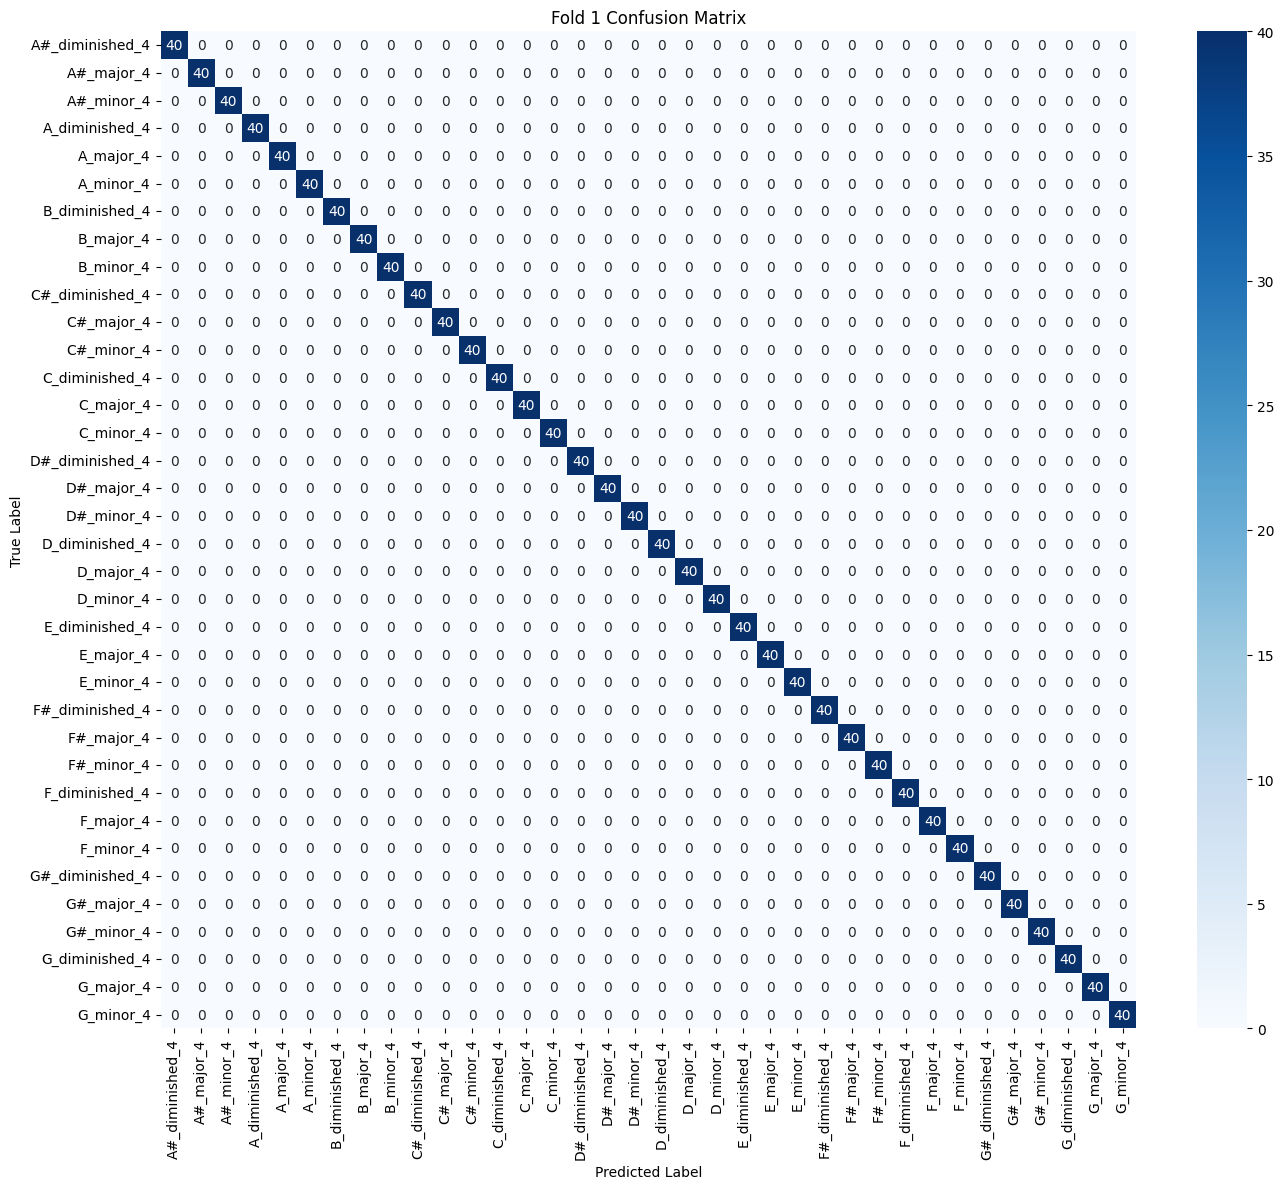

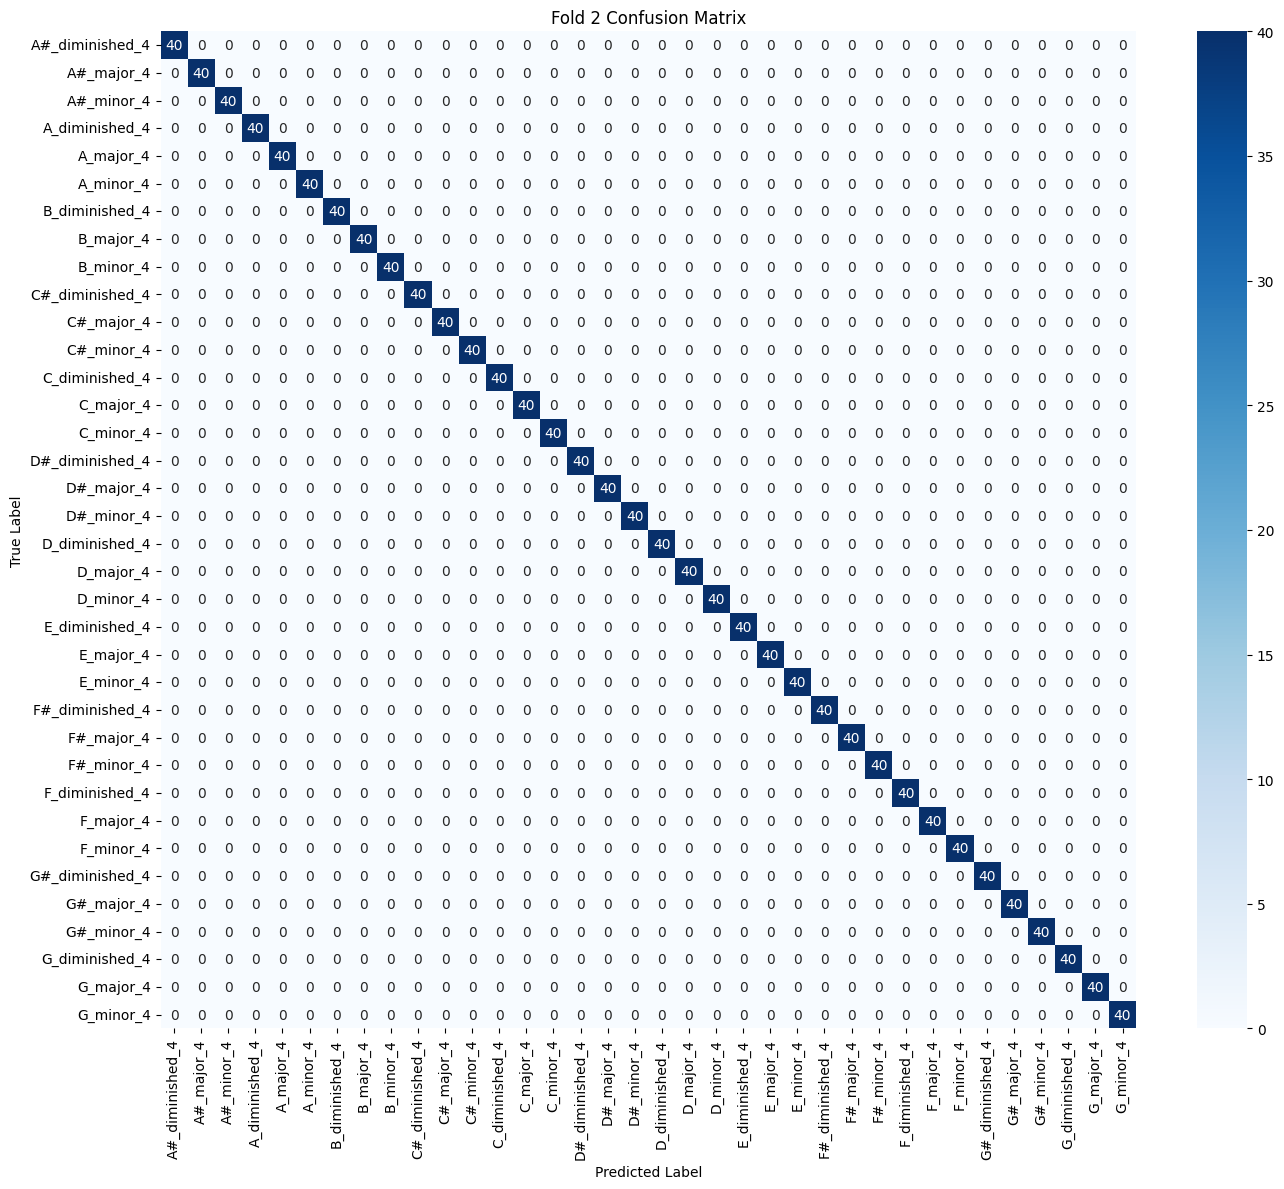

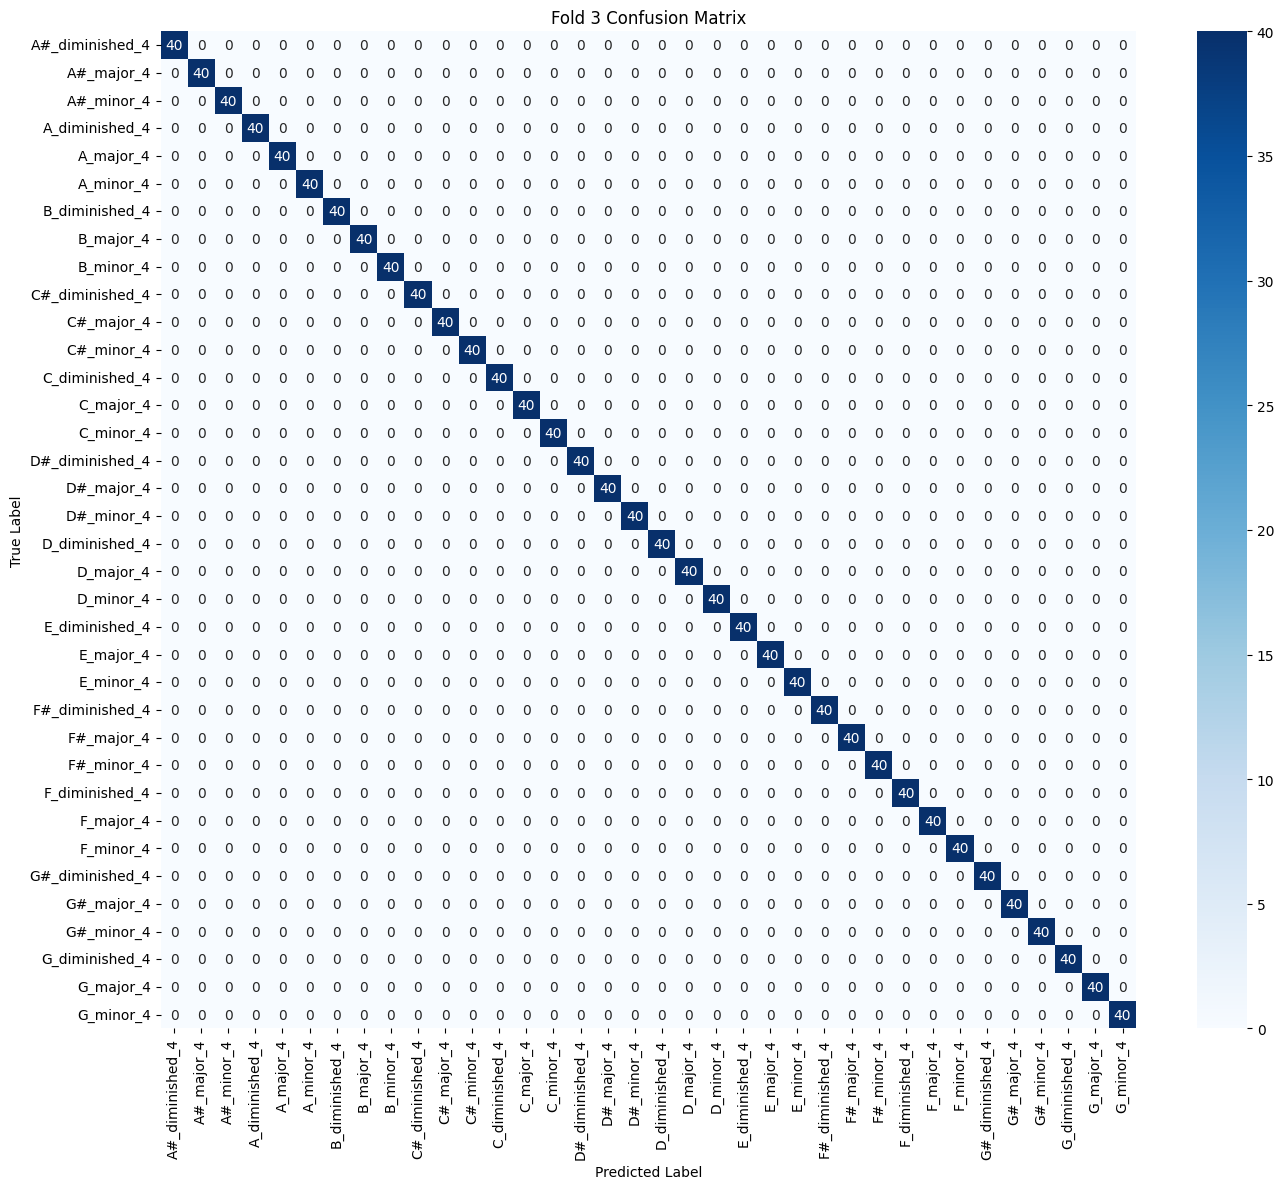

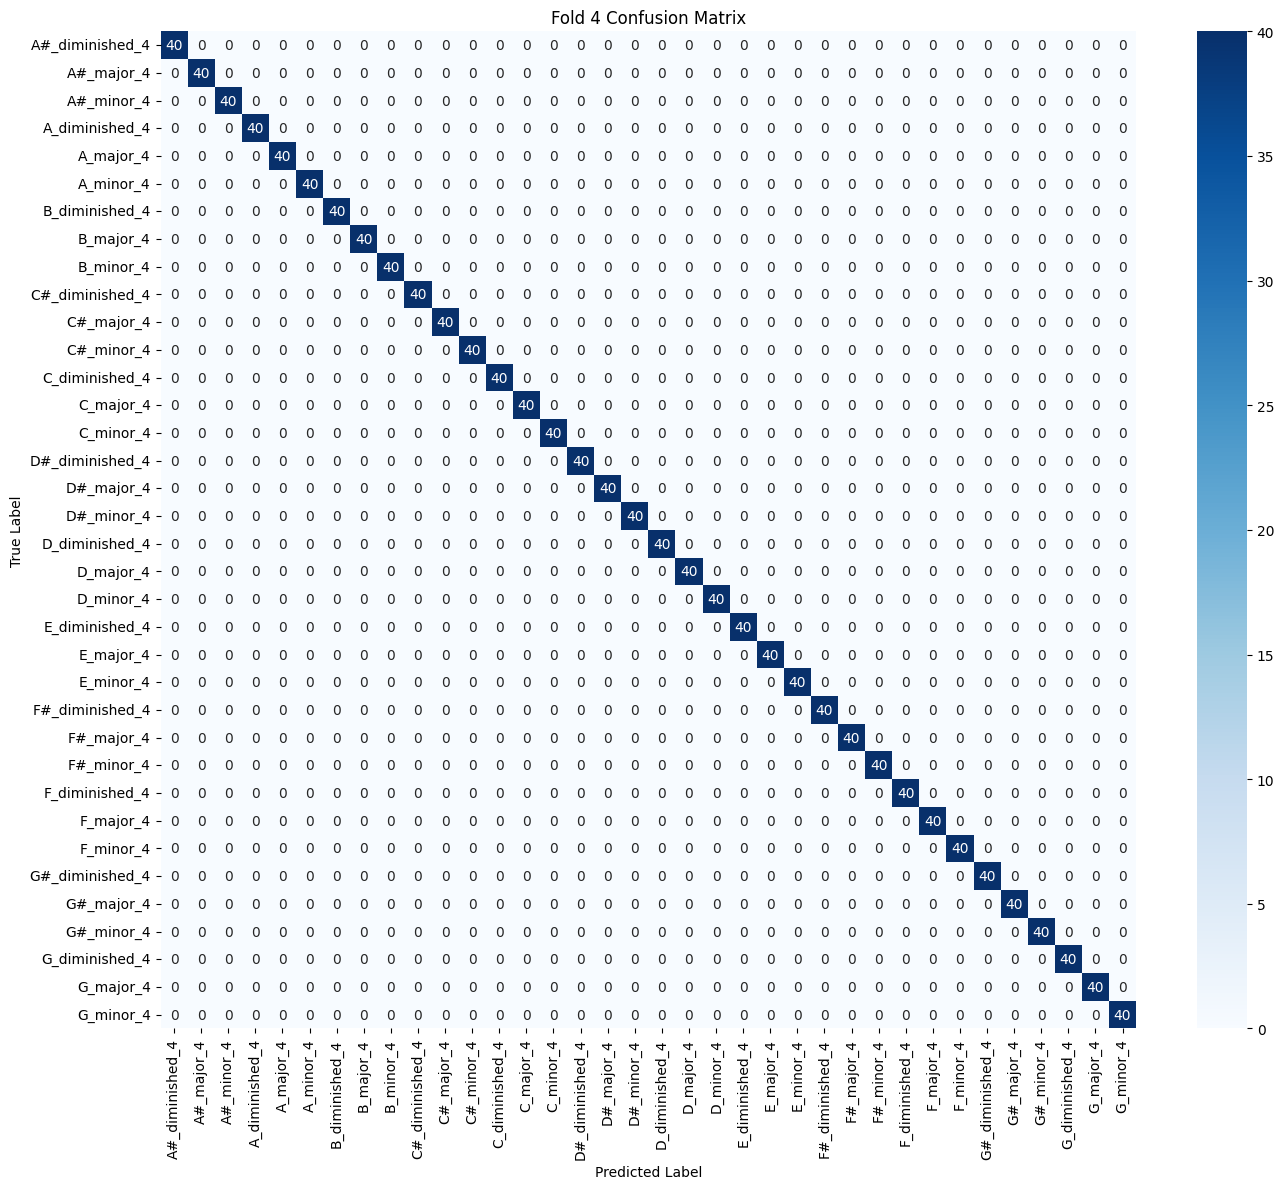

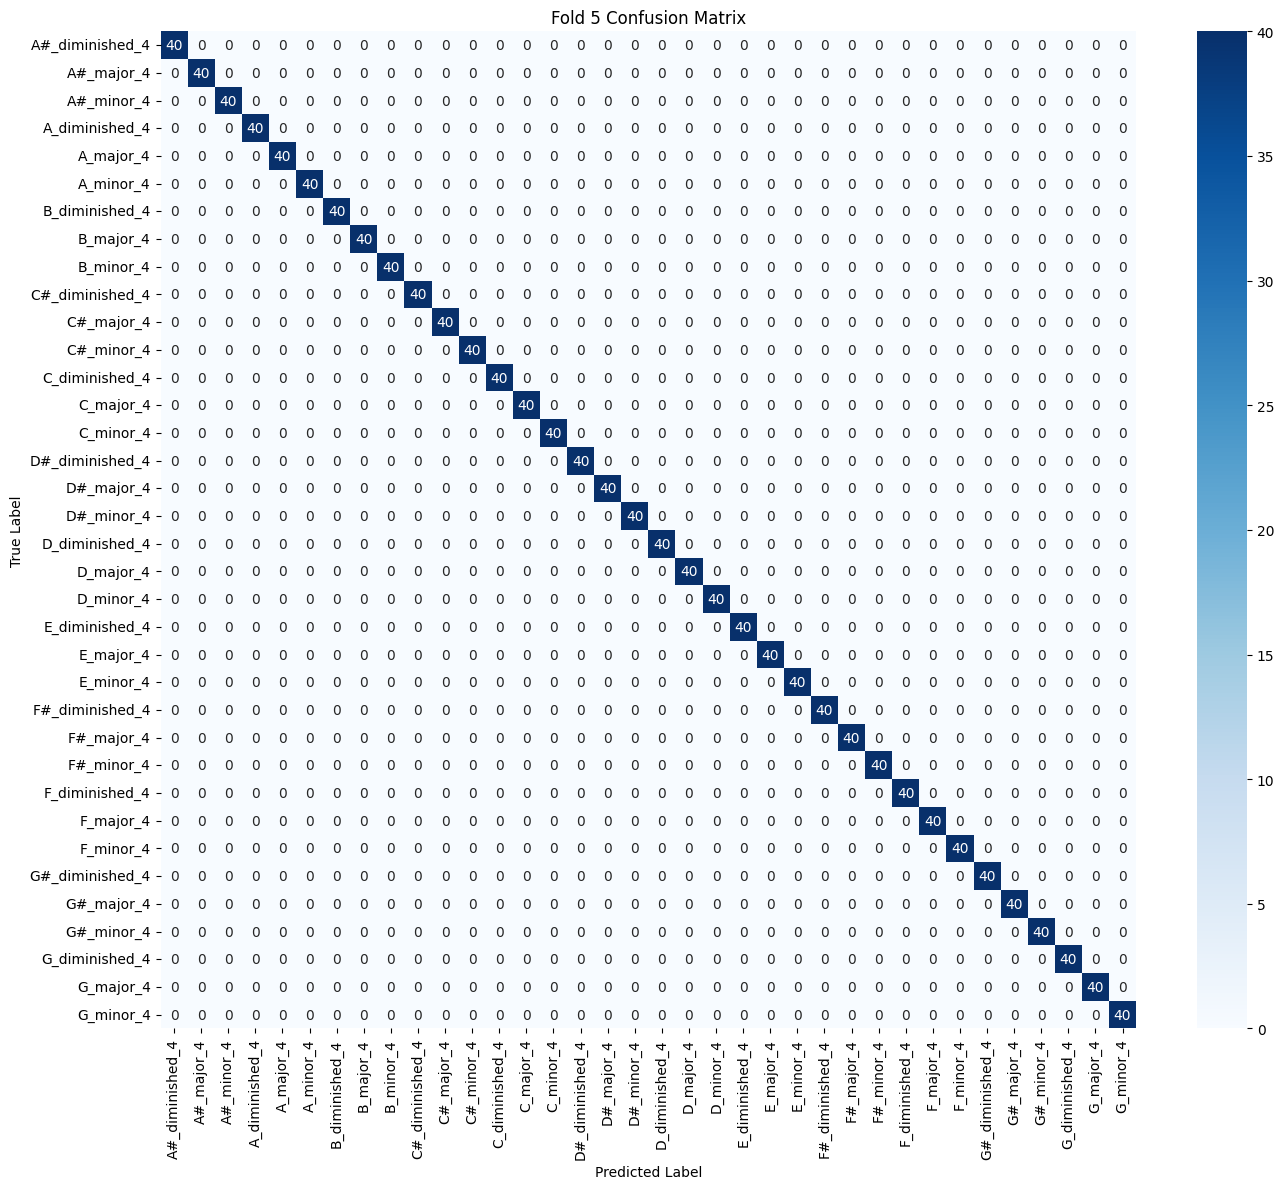

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

class_labels = label_encoder.classes_

for i, cm in enumerate(sfold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

### Accuracy & Loss Plot

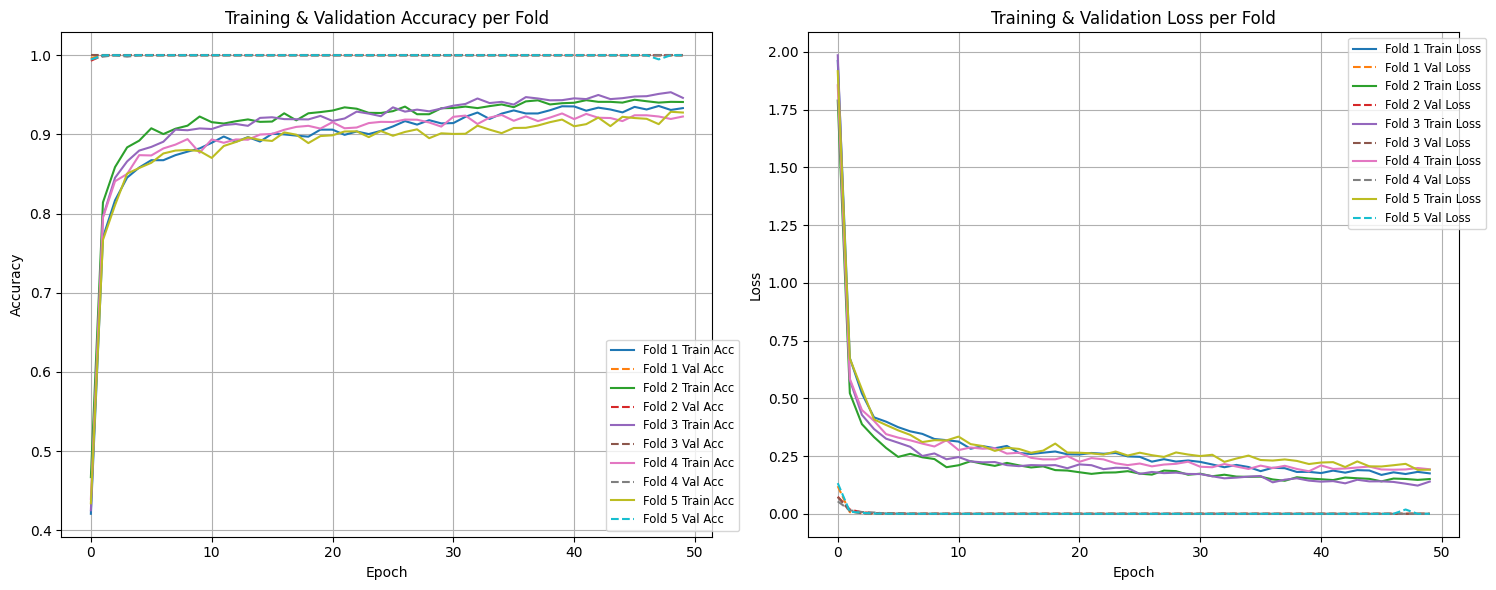

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
for i, history_obj in enumerate(sfold_histories):
    plt.plot(history_obj.history['accuracy'],
             label=f'Fold {i+1} Train Acc')
    plt.plot(history_obj.history['val_accuracy'],
             linestyle='--', label=f'Fold {i+1} Val Acc')

plt.title('Training & Validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right', bbox_to_anchor=(1.05, 0), fontsize='small')
plt.grid(True)

# --- Loss ---
plt.subplot(1, 2, 2)
for i, history_obj in enumerate(sfold_histories):
    plt.plot(history_obj.history['loss'],
             label=f'Fold {i+1} Train Loss')
    plt.plot(history_obj.history['val_loss'],
             linestyle='--', label=f'Fold {i+1} Val Loss')

plt.title('Training & Validation Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

### Mean & Std Deviation

In [ ]:
import numpy as np

# Collect final-epoch train/val metrics from each fold's history
train_accs = [h.history['accuracy'][-1]     for h in sfold_histories]
val_accs   = [h.history['val_accuracy'][-1] for h in sfold_histories]
train_losses = [h.history['loss'][-1]       for h in sfold_histories]
val_losses   = [h.history['val_loss'][-1]   for h in sfold_histories]

print("=" * 73)
print("         Stratified K-Fold Cross-Validation Summary (per fold)")
print("=" * 73)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
for i in range(len(sfold_accuracies)):
    print(f"  Fold {i+1:>1}  {train_accs[i]:>10.4f}  {val_accs[i]:>10.4f}  {sfold_accuracies[i]:>10.4f}  {train_losses[i]:>11.4f}  {val_losses[i]:>10.4f}  {sfold_losses[i]:>10.4f}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(f"  {'Mean':>6}  {np.mean(train_accs):>10.4f}  {np.mean(val_accs):>10.4f}  {np.mean(sfold_accuracies):>10.4f}  {np.mean(train_losses):>11.4f}  {np.mean(val_losses):>10.4f}  {np.mean(sfold_losses):>10.4f}")
print(f"  {'Std':>6}  {np.std(train_accs):>10.4f}  {np.std(val_accs):>10.4f}  {np.std(sfold_accuracies):>10.4f}  {np.std(train_losses):>11.4f}  {np.std(val_losses):>10.4f}  {np.std(sfold_losses):>10.4f}")
print("=" * 73)

         Stratified K-Fold Cross-Validation Summary (per fold)
           Train Acc     Val Acc    Test Acc   Train Loss    Val Loss   Test Loss
  ------  ----------  ----------  ----------  -----------  ----------  ----------
  Fold 1      0.9333      1.0000      1.0000       0.1750      0.0000      0.0000
  Fold 2      0.9410      1.0000      1.0000       0.1506      0.0000      0.0000
  Fold 3      0.9462      1.0000      1.0000       0.1395      0.0000      0.0000
  Fold 4      0.9226      1.0000      1.0000       0.1927      0.0000      0.0000
  Fold 5      0.9277      1.0000      1.0000       0.1908      0.0001      0.0001
  ------  ----------  ----------  ----------  -----------  ----------  ----------
    Mean      0.9341      1.0000      1.0000       0.1697      0.0000      0.0000
     Std      0.0086      0.0000      0.0000       0.0214      0.0001      0.0000


### Per Class Accuracies

Per-Class Accuracy (Mean ± Std across folds)
              Class  Mean Acc  Std Acc
1   A#_diminished_4       1.0      0.0
2        A#_major_4       1.0      0.0
3         D_minor_4       1.0      0.0
4    E_diminished_4       1.0      0.0
5         E_major_4       1.0      0.0
6         E_minor_4       1.0      0.0
7   F#_diminished_4       1.0      0.0
8        F#_major_4       1.0      0.0
9        F#_minor_4       1.0      0.0
10   F_diminished_4       1.0      0.0
11        F_major_4       1.0      0.0
12        F_minor_4       1.0      0.0
13  G#_diminished_4       1.0      0.0
14       G#_major_4       1.0      0.0
15       G#_minor_4       1.0      0.0
16   G_diminished_4       1.0      0.0
17        G_major_4       1.0      0.0
18        D_major_4       1.0      0.0
19   D_diminished_4       1.0      0.0
20       D#_minor_4       1.0      0.0
21        B_minor_4       1.0      0.0
22       A#_minor_4       1.0      0.0
23   A_diminished_4       1.0      0.0
24        A_major_4

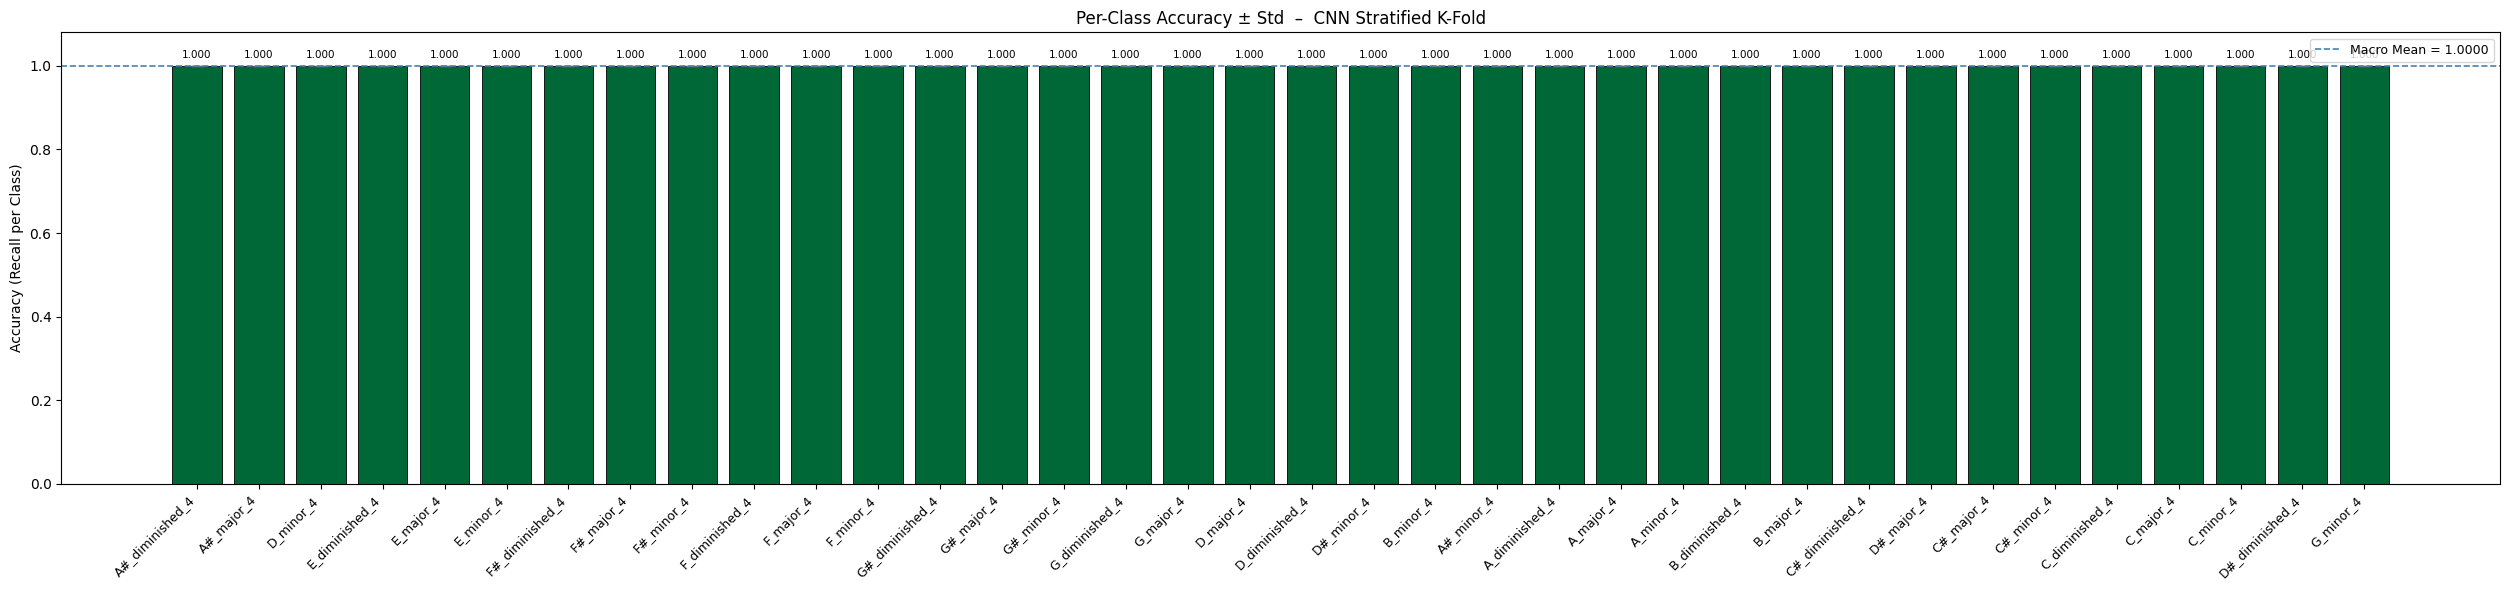

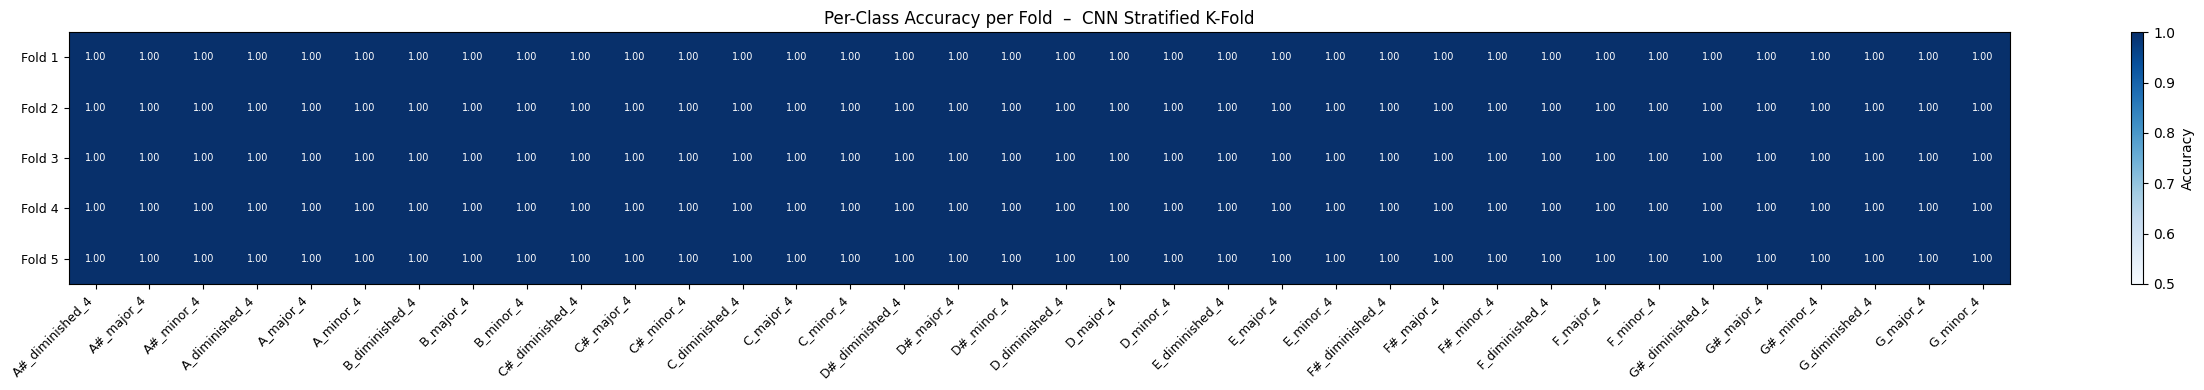

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Extract per-class accuracy for every fold ──────────────────────────────
class_names = label_encoder.classes_          # shape: (n_classes,)
n_folds     = len(sfold_confusion_matrices)
n_classes   = len(class_names)

# per_class_acc[fold, class] = recall of that class in that fold
per_class_acc = np.zeros((n_folds, n_classes))

for fold_idx, cm in enumerate(sfold_confusion_matrices):
    row_sums = cm.sum(axis=1)                     # true counts per class
    with np.errstate(divide='ignore', invalid='ignore'):
        acc = np.where(row_sums > 0, cm.diagonal() / row_sums, np.nan)
    per_class_acc[fold_idx] = acc

# ── 2. Mean & Std across folds ────────────────────────────────────────────────
mean_acc = np.nanmean(per_class_acc, axis=0)
std_acc  = np.nanstd(per_class_acc,  axis=0)

# ── 3. Build summary DataFrame ────────────────────────────────────────────────
df_class_acc = pd.DataFrame({
    "Class":    class_names,
    "Mean Acc": mean_acc,
    "Std Acc":  std_acc,
})
df_class_acc = df_class_acc.sort_values("Mean Acc", ascending=False).reset_index(drop=True)
df_class_acc.index += 1                           # rank starts at 1

print("Per-Class Accuracy (Mean ± Std across folds)")
print("=" * 45)
print(df_class_acc.to_string())

# ── 4. Bar chart with error bars ──────────────────────────────────────────────
sorted_classes = df_class_acc["Class"].values
sorted_mean    = df_class_acc["Mean Acc"].values
sorted_std     = df_class_acc["Std Acc"].values

colors = plt.cm.RdYlGn(sorted_mean)              # red=low, green=high

fig, ax = plt.subplots(figsize=(max(10, n_classes * 0.7), 6))
bars = ax.bar(
    range(n_classes), sorted_mean,
    yerr=sorted_std, capsize=4,
    color=colors, edgecolor="black", linewidth=0.6,
    error_kw={"elinewidth": 1.2, "ecolor": "dimgray"}
)

ax.set_xticks(range(n_classes))
ax.set_xticklabels(sorted_classes, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (Recall per Class)")
ax.set_title("Per-Class Accuracy ± Std  –  CNN Stratified K-Fold")
ax.set_ylim(0, 1.08)
ax.axhline(y=sorted_mean.mean(), color="steelblue",
           linestyle="--", linewidth=1.2, label=f"Macro Mean = {sorted_mean.mean():.4f}")
ax.legend(fontsize=9)

for i, (m, s) in enumerate(zip(sorted_mean, sorted_std)):
    ax.text(i, m + s + 0.015, f"{m:.3f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.show()

# ── 5. Optional: per-fold heatmap ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(max(10, n_classes * 0.7), max(4, n_folds * 0.55)))
im = ax2.imshow(per_class_acc, aspect="auto", cmap="Blues", vmin=0.5, vmax=1)

ax2.set_xticks(range(n_classes))
ax2.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
ax2.set_yticks(range(n_folds))
ax2.set_yticklabels([f"Fold {i+1}" for i in range(n_folds)], fontsize=9)
ax2.set_title("Per-Class Accuracy per Fold  –  CNN Stratified K-Fold")
fig2.colorbar(im, ax=ax2, label="Accuracy")

for fold_i in range(n_folds):
    for cls_j in range(n_classes):
        val = per_class_acc[fold_i, cls_j]
        ax2.text(cls_j, fold_i, f"{val:.2f}", ha="center", va="center",
                 fontsize=7, color="black" if 0.35 < val < 0.85 else "white")

plt.tight_layout()
plt.show()

# Noisy Evaluation

## Load model & noisy features

In [2]:
import tensorflow as tf
clean_loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH + '.h5')
noisy_data = np.load(NOISY_FEATURES_PATH)
noisy_features = noisy_data['features']
noisy_labels = noisy_data['labels']

print("Features and labels loaded successfully.")

Features and labels loaded successfully.


## Evaluate

113/113 [==============================] - 2s 7ms/step


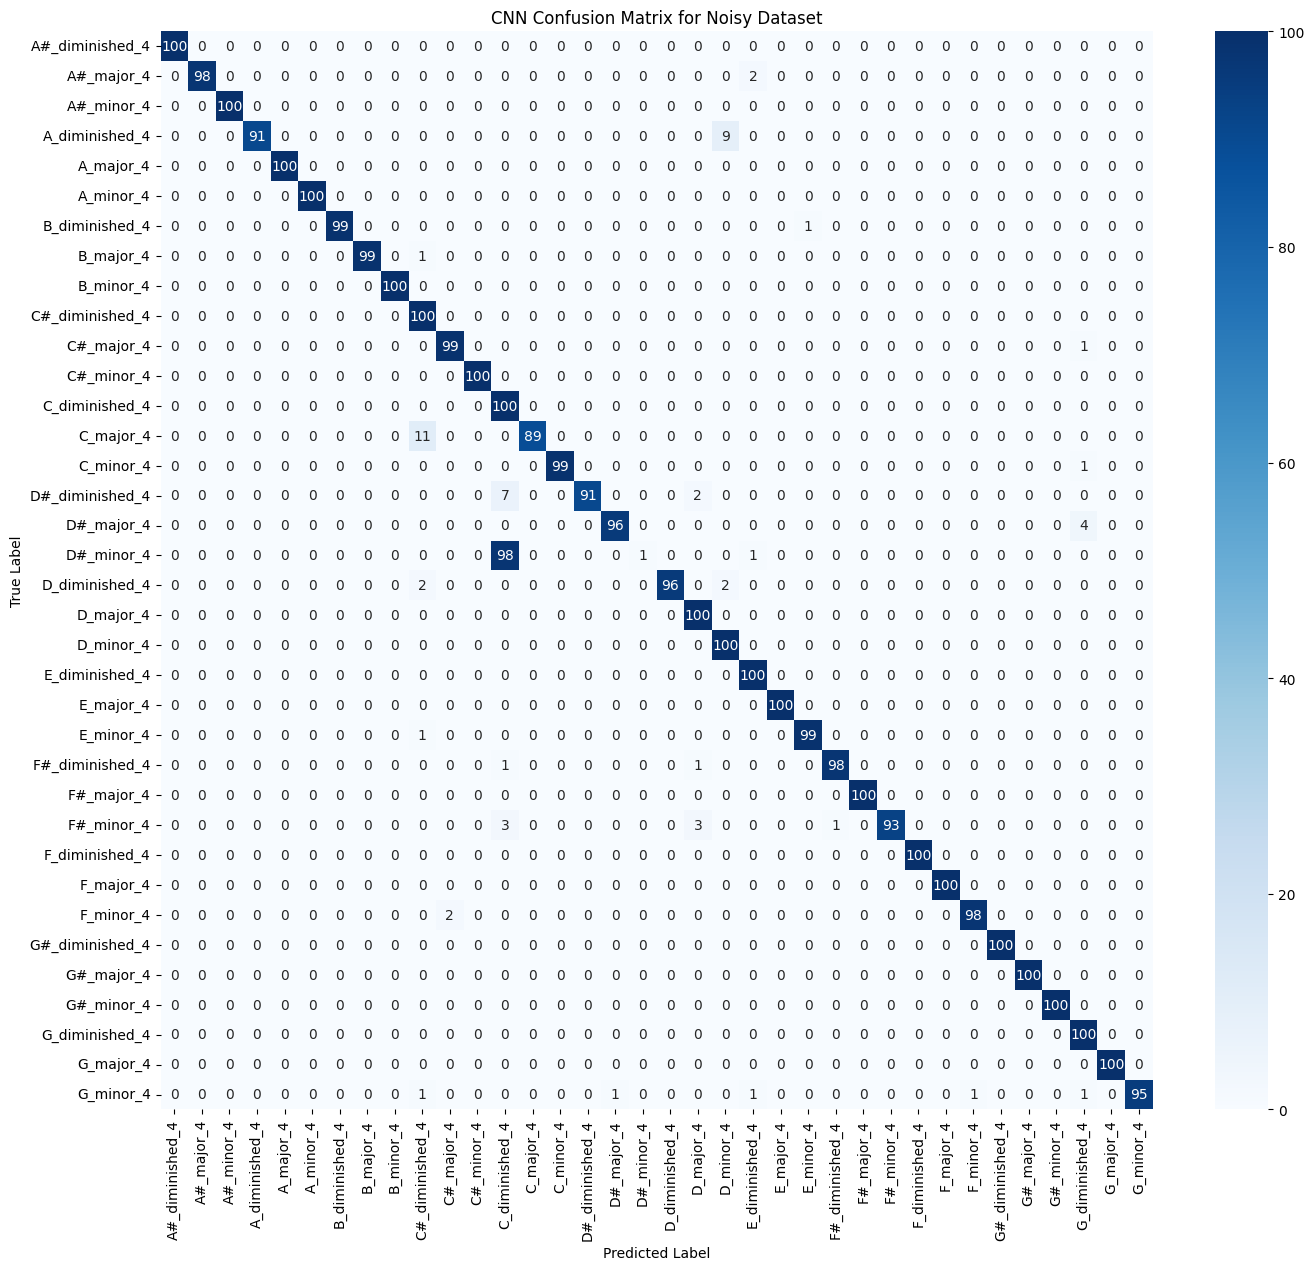

CNN Test Accuracy on Noisy Dataset: 0.9558333333333333

CNN Classification Report for Noisy Dataset:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00       100
     A#_major_4       1.00      0.98      0.99       100
     A#_minor_4       1.00      1.00      1.00       100
 A_diminished_4       1.00      0.91      0.95       100
      A_major_4       1.00      1.00      1.00       100
      A_minor_4       1.00      1.00      1.00       100
 B_diminished_4       1.00      0.99      0.99       100
      B_major_4       1.00      0.99      0.99       100
      B_minor_4       1.00      1.00      1.00       100
C#_diminished_4       0.86      1.00      0.93       100
     C#_major_4       0.98      0.99      0.99       100
     C#_minor_4       1.00      1.00      1.00       100
 C_diminished_4       0.48      1.00      0.65       100
      C_major_4       1.00      0.89      0.94       100
      C_minor_4       1.00      0.99      

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Fit label encoder on clean labels (all classes the model was trained on)
noisy_label_encoder = LabelEncoder()
noisy_label_encoder.fit(noisy_labels)
num_classes = len(noisy_label_encoder.classes_)

# Encode noisy labels using the clean label encoder
noisy_encoded_labels = noisy_label_encoder.transform(noisy_labels)
noisy_categorical_labels = to_categorical(noisy_encoded_labels, num_classes=num_classes)

# Reshape noisy_features to add a channel dimension
noisy_features_reshaped = np.expand_dims(noisy_features, axis=-1)

# Get predictions for the noisy test set
noisy_predictions = clean_loaded_model.predict(noisy_features_reshaped)
predicted_noisy_classes = np.argmax(noisy_predictions, axis=1)
actual_noisy_classes = np.argmax(noisy_categorical_labels, axis=1)

# Get class labels from the label encoder
class_labels = noisy_label_encoder.classes_

# Compute the confusion matrix
cm_noisy = confusion_matrix(actual_noisy_classes, predicted_noisy_classes)

# Plot the confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix for Noisy Dataset')
plt.show()

# Generate classification report
accuracy_noisy = accuracy_score(actual_noisy_classes, predicted_noisy_classes)
print(f"CNN Test Accuracy on Noisy Dataset: {accuracy_noisy}")

report_noisy = classification_report(actual_noisy_classes, predicted_noisy_classes, target_names=class_labels)
print("\nCNN Classification Report for Noisy Dataset:\n", report_noisy)